In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import ks_2samp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

mpl.rcParams.update({
    "text.usetex": False,               # Use LaTeX for all text
    "font.family": "serif",           # Use serif fonts (like LaTeX)
    "font.serif": ["DejaVu Serif"],  # Computer Modern is LaTeX's default
    "axes.labelsize": 12,
    'figure.dpi': 180, 
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    'font.weight': 'normal'
})

Load story genre data from the mat file and story_character_summary.csv.

In [334]:
import scipy.io

mat = scipy.io.loadmat('../datasets/archetypometricsdata2000.mat')
stories = mat['data_stories'][0,0]
storyverses = stories['storyverses']          # (341,1) story names
sci = stories['storycharacterindices']        # (341,1) each element: char indices (1-based)

In [335]:
# get comedy vs drama
# story_genre = pd.read_csv('../datasets/imdb_archetype_character_comedy_drama.csv', index_col=0) # XOR
story_genre = pd.read_csv('../datasets/imdb_archetype_character_comedy_drama.csv', index_col=0) # has handlabels as well as XOR

In [336]:
story_genre.head()

,character_name,character_story_pair,story_name,primary_archetype,max_archetype_ratio,match_type,imdb_tconst,imdb_titleType,imdb_primaryTitle,imdb_startYear,imdb_endYear,imdb_runtimeMinutes,imdb_genres,genre_label
0,Applejack,Applejack/My Little Pony: Friendship Is Magic,My Little Pony: Friendship Is Magic,Angel-Brute-Hero,4.879310,exact,tt1751105,tvSeries,My Little Pony: Friendship Is Magic,2010.0,2019.0,22.0,"Adventure,Animation,Comedy",Comedy
1,Twilight Sparkle,Twilight Sparkle/My Little Pony: Friendship Is...,My Little Pony: Friendship Is Magic,Diva-Angel-Hero,10.590790,exact,tt1751105,tvSeries,My Little Pony: Friendship Is Magic,2010.0,2019.0,22.0,"Adventure,Animation,Comedy",Comedy
2,Rarity,Rarity/My Little Pony: Friendship Is Magic,My Little Pony: Friendship Is Magic,Sophisticate-Diva-Hero,12.078822,exact,tt1751105,tvSeries,My Little Pony: Friendship Is Magic,2010.0,2019.0,22.0,"Adventure,Animation,Comedy",Comedy
3,Pinkie Pie,Pinkie Pie/My Little Pony: Friendship Is Magic,My Little Pony: Friendship Is Magic,Adventurer,11.830696,exact,tt1751105,tvSeries,My Little Pony: Friendship Is Magic,2010.0,2019.0,22.0,"Adventure,Animation,Comedy",Comedy
4,Spike,Spike/My Little Pony: Friendship Is Magic,My Little Pony: Friendship Is Magic,Angel-Outcast-Adventurer,11.792687,exact,tt1751105,tvSeries,My Little Pony: Friendship Is Magic,2010.0,2019.0,22.0,"Adventure,Animation,Comedy",Comedy


In [337]:
# story_genre[story_genre['story_name'].isin(['Arrested Development', 'WandaVision'])]

In [338]:
# # If imdb_genres contains comedy, genre_label is comedy, else if it contains drama, genre_label is drama, else genre_label is unknown
# def label_genre(g):
#     if not isinstance(g, str):   # catches NaN or anything non‑string
#         return "Other"
    
#     has_comedy = "Comedy" in g
#     has_drama  = "Drama" in g

#     if has_comedy and has_drama:
#         return "Both"
#     if has_comedy:
#         return "Comedy"
#     if has_drama:
#         return "Drama"
#     return "Other"

# story_genre["genre_label"] = story_genre["imdb_genres"].apply(label_genre)


# story_genre["genre_label"].value_counts()

In [339]:
# Apply Michael's XOR logic: keep only stories that are comedy or drama, but not both
story_imdb = pd.read_csv('../prepared_data/story_imdb_mapping.csv')

genres = story_imdb.groupby("story_name")["imdb_genres"].first().fillna("")
is_comedy = genres.str.contains("Comedy", na=False)
is_drama = genres.str.contains("Drama", na=False)
pure = is_comedy ^ is_drama

genre_labels = pd.Series(
    np.where(is_comedy[pure], "Comedy", "Drama"),
    index=genres.index[pure],
    name="genre_label"
)

story_genre["genre_label"] = story_genre["story_name"].map(genre_labels)
story_genre["genre_label"].value_counts()

genre_label
Drama     828
Comedy    352
Name: count, dtype: int64

In [340]:
comedy_character_list = []
drama_character_list = []

# get comedy and drama character lists from story_genre dataframe
# story_genre.index holds the integer character index (0-1999) from the CSV
for i in range(len(story_genre)):
    genre = story_genre.iloc[i]['genre_label']
    char_idx = story_genre.index[i]  # integer index into the 2000-char array
    if genre == 'Comedy':
        comedy_character_list.append(char_idx)
    elif genre == 'Drama':
        drama_character_list.append(char_idx)

print(f"Comedy characters: {len(comedy_character_list)}")
print(f"Drama characters: {len(drama_character_list)}")

Comedy characters: 352
Drama characters: 828


In [341]:
828+352

1180

In [342]:
story_genre[story_genre['genre_label'].isin(["Comedy", "Drama"])].story_name.nunique()

203

How many comedy & drama stories are there?

In [343]:
story_genre[story_genre['genre_label'] == 'Comedy']['story_name'].nunique()

65

In [344]:
story_genre[story_genre['genre_label'] == 'Drama']['story_name'].nunique()

138

Upload U matrix, V matrix, and the raw_A matrix.

In [345]:
U_matrix = np.loadtxt('../datasets/data/plain/current/2000/data_archetype_space_U.txt', delimiter=' ')
V_matrix = np.loadtxt('../datasets/data/plain/current/2000/data_archetype_space_V.txt', delimiter=' ')
raw_A = np.loadtxt('../datasets/data/plain/current/2000/data_raw_A.txt', delimiter=' ')
norm_traits = np.loadtxt('../datasets/data/plain/current/2000/data_archetype_space_trait_component_norms.txt')

Transpose the U matrix to match dimensions of the character space.

In [346]:
U_matrix_T = U_matrix.transpose()

Build lists of comedy and drama character indices for later indexing.

In [347]:
# character names from mat file
char_typenames = mat['data_characters'][0,0]['character_typenames']  # (2000,1)
char_names = [char_typenames[i,0][0] for i in range(len(char_typenames))]

# DataFrames for each genre
comedy_chars_df = pd.DataFrame({
    'index': comedy_character_list,
    'character': [char_names[i] for i in comedy_character_list]
})
drama_chars_df = pd.DataFrame({
    'index': drama_character_list,
    'character': [char_names[i] for i in drama_character_list]
})

In [348]:
comedy_chars_df.head()  # just a check

,index,character
0,0,Applejack
1,1,Twilight Sparkle
2,2,Rarity
3,3,Pinkie Pie
4,4,Spike


Here's where we combine the U matrix which is all components by trait.

And then we normalize it.

In [349]:
archetype_space = np.matmul(U_matrix_T,raw_A)

row_magnitudes = np.linalg.norm(raw_A, axis=1)
max_value = np.max(row_magnitudes)
print(max_value)
norm_constant_traits = 100/max_value

archetype_space_by_genre = archetype_space

13.410878718413644


In [350]:
archetype_space.shape # another check, should be (464, 2000)

(464, 2000)

Here we have comedy and drama subsets of the archetype space by genre.

In [351]:
# all dimensions, comedy and drama
selected_comedy_dims = archetype_space_by_genre[:, comedy_character_list]
selected_drama_dims = archetype_space_by_genre[:, drama_character_list]

# first six dimensions, comedy and drama
selected_comedy_6_dims = selected_comedy_dims[0:6,:]
selected_drama_6_dims = selected_drama_dims[0:6,:]

In [352]:
selected_comedy_dims

array([[ 2.1730315e+00,  3.1797615e+00,  2.7448767e+00, ...,
         2.8141765e+00,  2.5683858e+00, -8.8554920e-01],
       [-1.8128114e+00, -1.9962400e+00, -5.6412950e-01, ...,
        -1.2156008e+00, -7.0769340e-01, -1.6599769e+00],
       [ 1.5417338e+00, -4.0089470e-01,  1.1334530e+00, ...,
        -1.6855709e+00,  6.7639500e-02, -1.6268080e-01],
       ...,
       [ 2.7423600e-02,  1.4907200e-02, -1.5078600e-02, ...,
        -1.9712200e-02, -4.7900000e-02,  4.8656300e-02],
       [ 3.1399600e-02, -2.7165000e-03, -7.3993000e-03, ...,
         8.0970000e-04, -5.1209400e-02,  7.2852000e-03],
       [-2.7170000e-04,  1.1378000e-03,  2.3277000e-03, ...,
         6.4786000e-03,  7.1777900e-02,  8.3067000e-03]])

We can take the means of any of these subsets.

In [353]:
# comedy and drama, first 6 dimensions
comedy_means = np.mean(selected_comedy_6_dims, axis=1)
drama_means = np.mean(selected_drama_6_dims, axis=1)
print(f"Comedy means, first 6 dimensions: {comedy_means}")
print(f"Drama means, first 6 dimensions: {drama_means}")

Comedy means, first 6 dimensions: [ 1.19705899 -0.02204828  0.89019342  0.45329757 -0.51674775 -0.07405558]
Drama means, first 6 dimensions: [ 1.74403856  0.22491321  0.33644628  0.2076783  -0.49078784 -0.10762395]


We can calculate the radii of gyration too! 

In [354]:
def radius_gyration(A): 

    # Step 1: Define your 3x8 matrix
    # Each column is a 3D point: [x, y, z]
    #A = selected_male_3_dims

    # Step 2: Compute the centroid (mean along columns)
    centroid = np.mean(A, axis=1, keepdims=True)  # shape (3, 1)

    # Step 3: Subtract centroid to get differences
    differences = A - centroid  # shape (3, 8)

    # Step 4: Compute squared distances of each point to the centroid
    squared_distances = np.sum(differences ** 2, axis=0)  # shape (8,)

    # Step 5: Compute the mean of the squared distances
    mean_squared_distance = np.mean(squared_distances)

    # Step 6: Take square root to get the radius of gyration
    radius_of_gyration = np.sqrt(mean_squared_distance)

# Output
    return radius_of_gyration


We want to balance sample sizes (there are many more comedy characters than drama characters.)

In [ ]:
def bootstrap_columns(matrix, n_samples=None):
    """
    Bootstraps (samples with replacement) columns from a 2D matrix.
    """
    n_cols = matrix.shape[1]
    if n_samples is None:
        n_samples = n_cols

    indices = np.random.choice(n_cols, size=n_samples, replace=True)
    return matrix[:, indices]

def bootstrap_summary_statistic(matrix, n_iterations=100, n_samples=None, statistic_func=np.mean):
    """
    Performs bootstrap sampling of columns multiple times, computes a summary statistic on each sample,
    and returns the list of summary statistics.

    Parameters:
        matrix (np.ndarray): Original 2D matrix.
        n_iterations (int): Number of bootstrap iterations.
        n_samples (int): Number of columns to sample per iteration.
        statistic_func (function): Function to compute a summary statistic on the sampled matrix.

    Returns:
        np.ndarray: Array of summary statistics (length = n_iterations).
    """
    if n_samples is None:
        n_samples = matrix.shape[1]

    summary_stats = np.zeros(n_iterations)

    for i in range(n_iterations):
        boot_sample = bootstrap_columns(matrix, n_samples=n_samples)
        summary_stats[i] = radius_gyration(boot_sample)

    return summary_stats

if __name__ == "__main__":
    # Example usage
    original_matrix_comedy = selected_comedy_dims
    original_matrix_drama = selected_drama_dims

    n_iterations = 5000     # Number of bootstrap runs
    n_samples = 500       # Number of columns sampled per bootstrap

    # Compute summary statistics (mean of bootstrapped matrix) for each iteration
    summary_comedy = bootstrap_summary_statistic(original_matrix_comedy, n_iterations=n_iterations, n_samples=n_samples)
    summary_drama = bootstrap_summary_statistic(original_matrix_drama, n_iterations=n_iterations, n_samples=n_samples)

    # Final result: mean of summary statistics (can also return percentiles, etc.)
    print(f"Bootstrapped mean of radius of gyration (comedy): {np.mean(summary_comedy):.4f}")
    print(f"Bootstrapped mean of radius of gyration (drama): {np.mean(summary_drama):.4f}")

    # Optional: Show spread
    print(f"95% CI (comedy): {np.percentile(summary_comedy, [2.5, 97.5])}")
    print(f"95% CI (drama): {np.percentile(summary_drama, [2.5, 97.5])}")


We can plot it as well! 

/var/folders/nb/clbb898j3mncw_pfsj58zfv80000gn/T/ipykernel_72870/2893029382.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


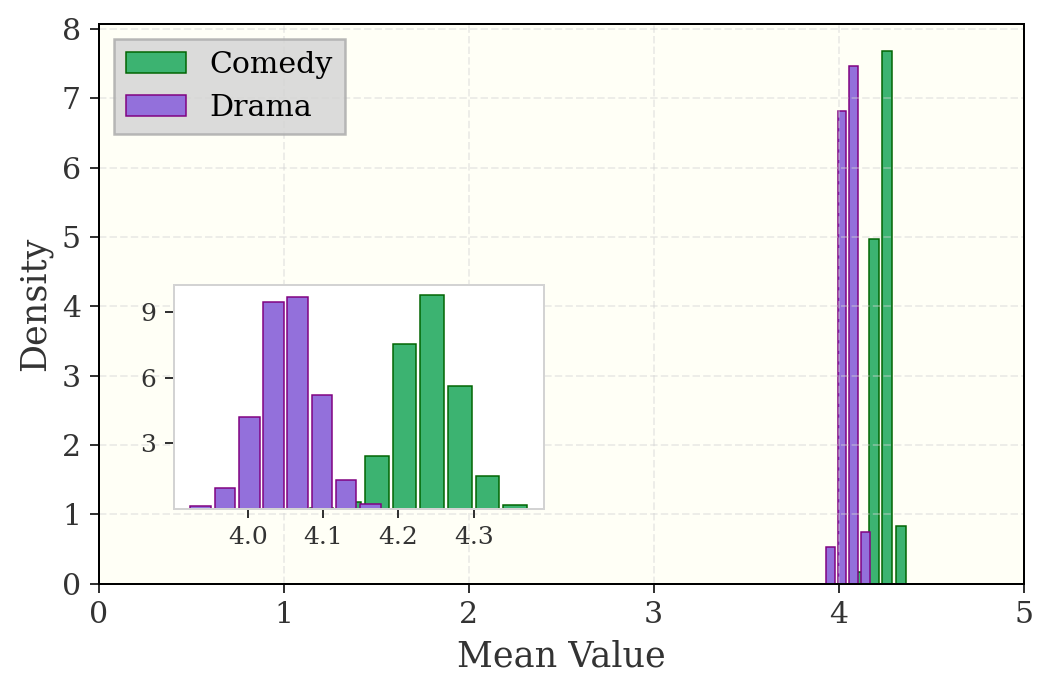

In [ ]:
# Dark grey color for axes, labels, ticks
dark_grey = '#333333'

# Create figure and main axes
fig, ax = plt.subplots(figsize=(6, 4))

# Main axes background
ax.set_facecolor((1.0, 1.0, 0.965))

# -------------------
# Main histograms with spacing
# -------------------
ax.hist(
    summary_comedy, bins=4, density=True,
    color='mediumseagreen',
    edgecolor='darkgreen', linewidth=0.6,
    label='Comedy',
    rwidth=0.75,
    align='mid',
)
ax.hist(
    summary_drama, bins=4, density=True,
    color='mediumpurple',
    edgecolor='purple', linewidth=0.6,
    label='Drama',
    rwidth=0.75,
    align='mid',
)

ax.set_xlim(0, 5)
ax.set_xlabel('Mean Value', fontsize=14, color=dark_grey)
ax.set_ylabel('Density', fontsize=14, color=dark_grey)
ax.tick_params(axis='both', labelsize=12, colors=dark_grey)
ax.grid(True, linestyle='--', alpha=0.4)

# -------------------
# Only outer spines black
# -------------------
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# -------------------
# Legend with dark grey background and black border
# -------------------
leg = ax.legend(frameon=True, edgecolor='darkgrey', facecolor='lightgrey', fontsize=12, fancybox=False)

# -------------------
# Inset axes (slightly smaller)
# -------------------
ax_inset = inset_axes(
    ax,
    width="40%",
    height="40%",
    loc='lower left',
    borderpad=3
)

ax_inset.set_facecolor('white')
ax_inset.patch.set_alpha(1)
ax_inset.set_zorder(5)

# Inset histograms with spacing
ax_inset.hist(
    summary_comedy, bins=8, density=True,
    color='mediumseagreen',
    edgecolor='darkgreen', linewidth=0.6,
    rwidth=0.85,
    align='mid',
)
ax_inset.hist(
    summary_drama, bins=8, density=True,
    color='mediumpurple',
    edgecolor='purple', linewidth=0.6,
    rwidth=0.85,
    align='mid',
)

# -------------------
# Fix inset tick marks
# -------------------
ax_inset.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
ax_inset.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
ax_inset.tick_params(axis='both', labelsize=10, colors=dark_grey)

# Remove inset title and grid
ax_inset.set_title('')
ax_inset.grid(False)

# Layout and save
plt.tight_layout()
# plt.savefig("../figures/bootstrapped_radii_of_gyration_comedy_drama_xor.pdf", bbox_inches='tight')
# plt.show()


## Archetypes by Genre

Next, we can plot archetypes by genre (comedy vs drama).

Here is plotting code for the six archetype pairs by genre.

Fool-Hero
K-S Statistic: 0.16777832674571805
P-value: 1.5049047645300208e-06
Angel-Demon
K-S Statistic: 0.12985836627140976
P-value: 0.0004261403030898142
Traditionalist-Adventurer
K-S Statistic: 0.14263559508124726
P-value: 7.477901482021679e-05
Lone Wolf-Diva
K-S Statistic: 0.11091897233201581
P-value: 0.0041568941468243205
Outcast-Sophisticate
K-S Statistic: 0.06317248572683355
P-value: 0.263934510753468
Brute-Geek
K-S Statistic: 0.04670344751866491
P-value: 0.6326966068566325


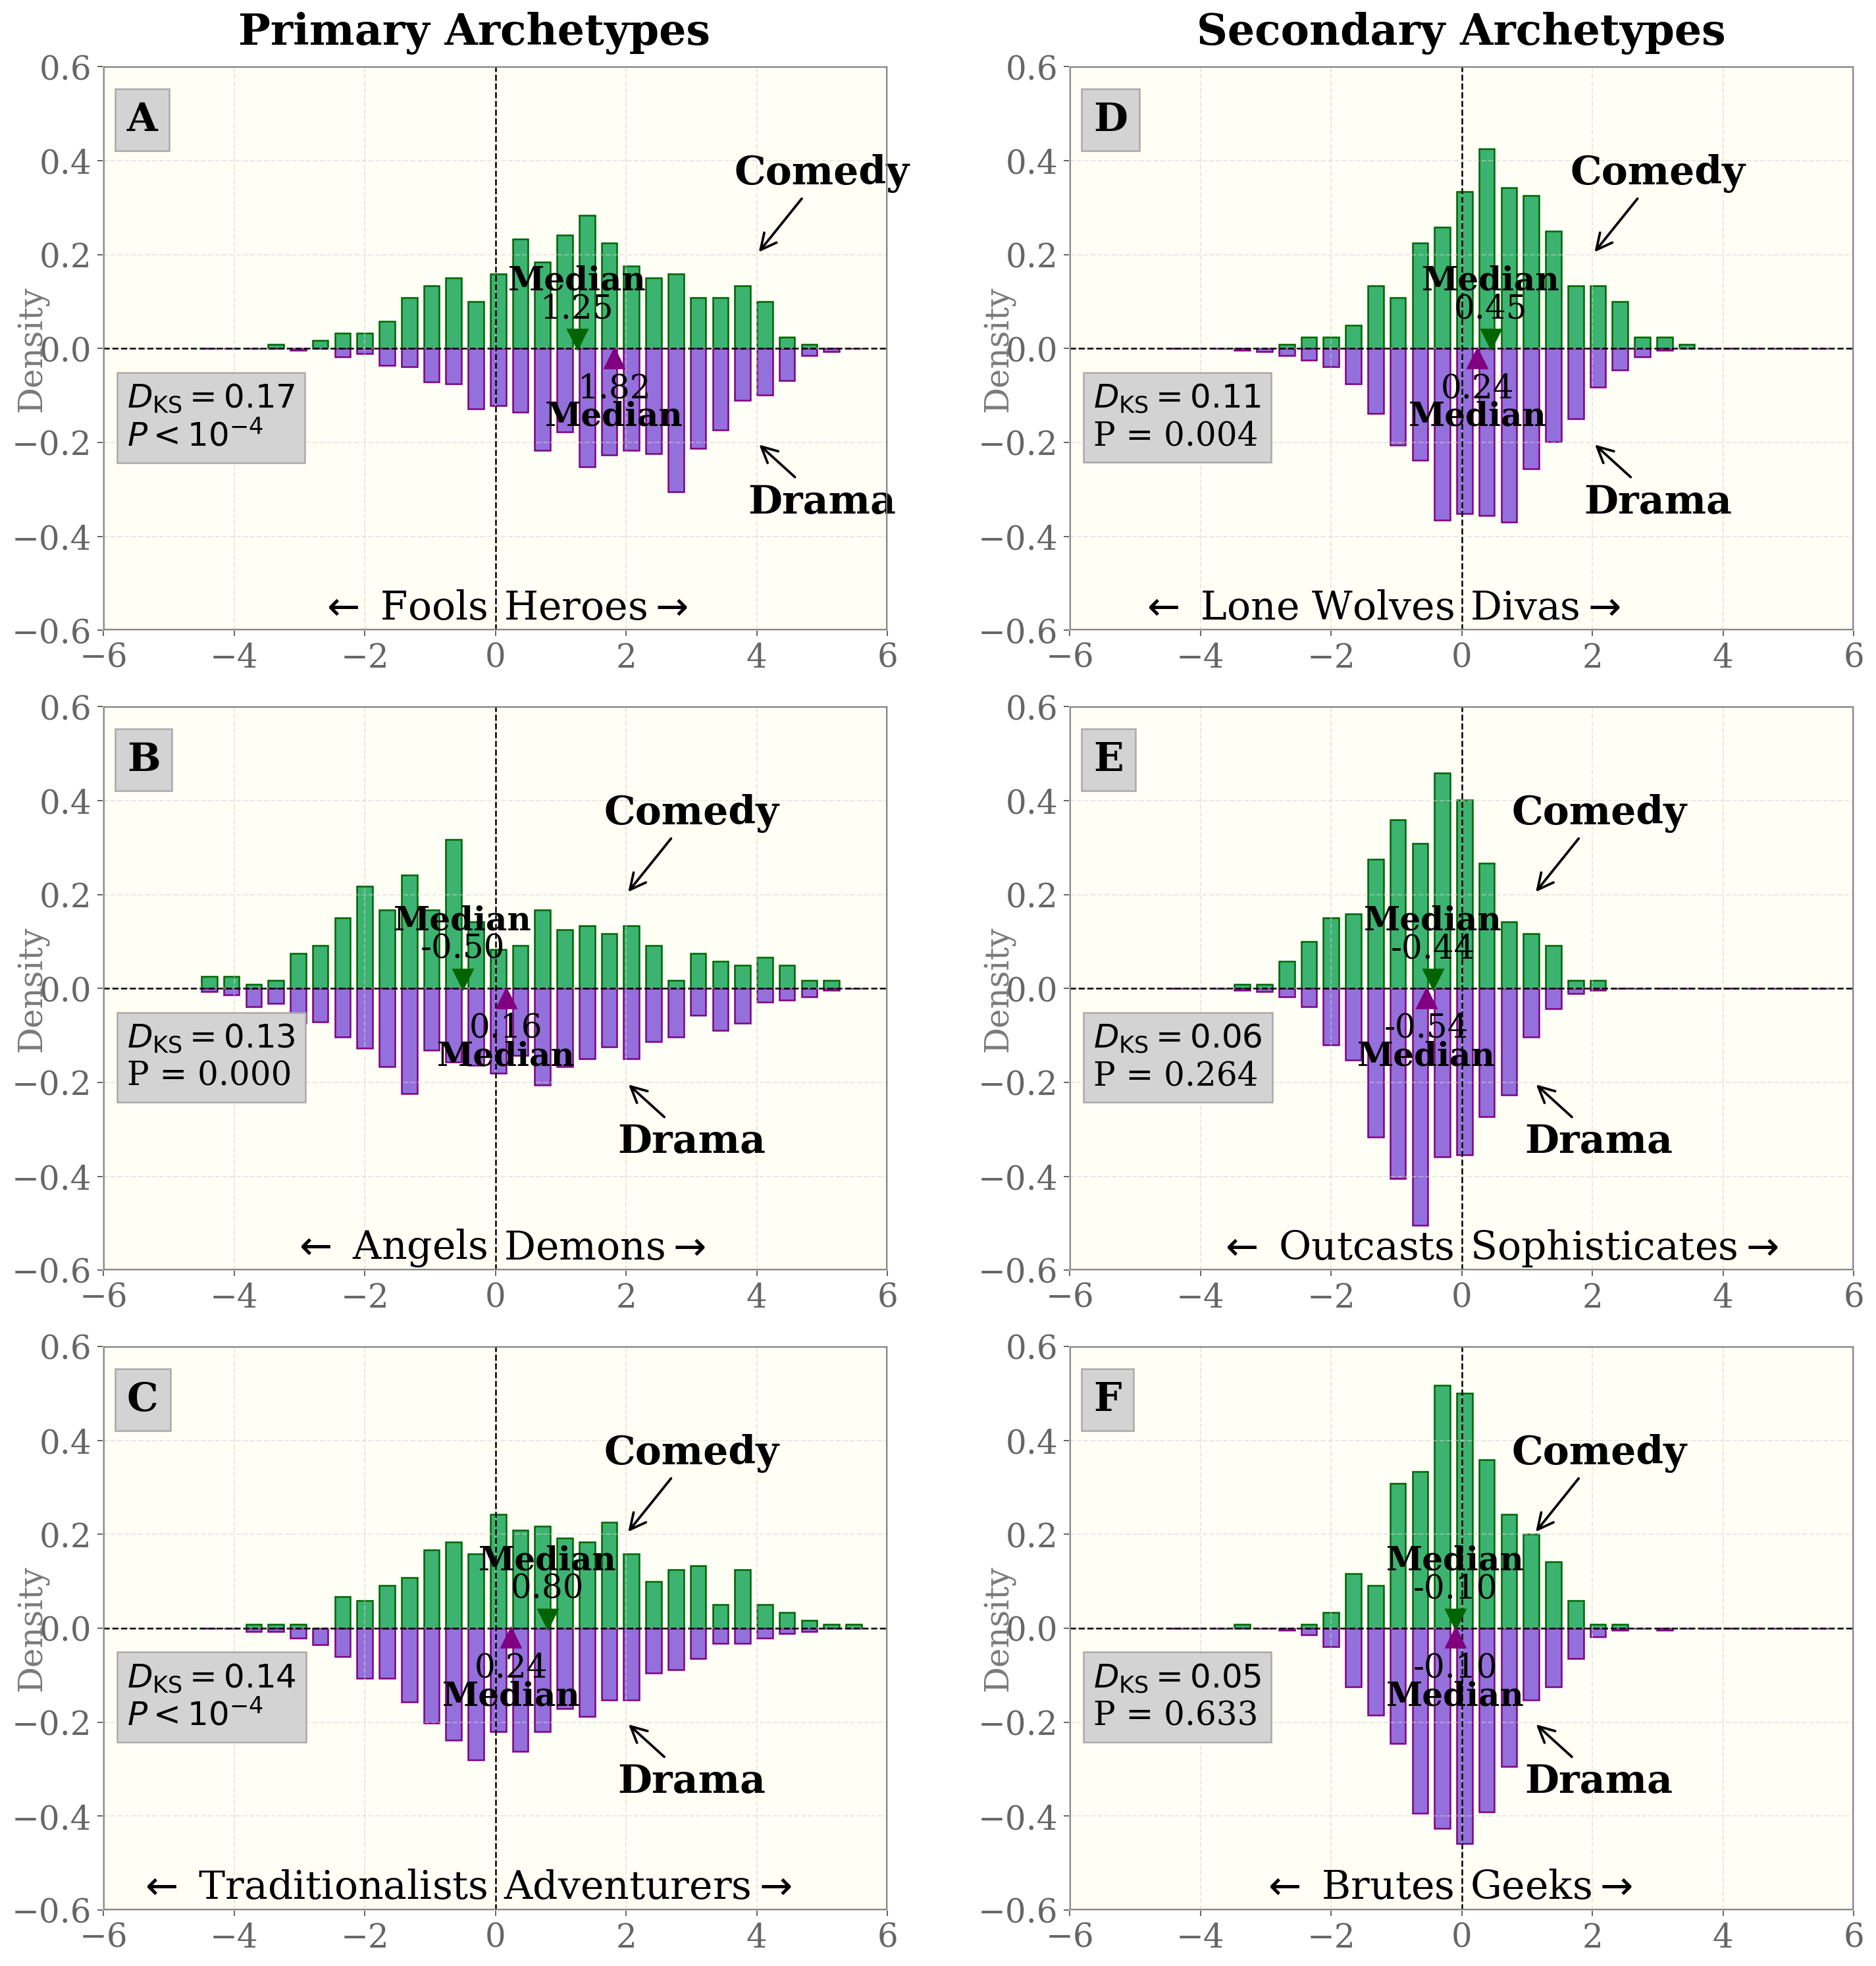

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

# Labels
dimension_labels = [
    "Fool-Hero",
    "Angel-Demon",
    "Traditionalist-Adventurer",
    "Lone Wolf-Diva",
    "Outcast-Sophisticate",
    "Brute-Geek"
]

right_labels = ["Heroes", "Demons", "Adventurers", "Divas", "Sophisticates", "Geeks"]
left_labels = ["Fools", "Angels", "Traditionalists", "Lone Wolves", "Outcasts", "Brutes"]

fig, axes = plt.subplots(3, 2, figsize=(17, 18))

fig.text(
    0.26, 1.01,
    "Primary Archetypes",
    ha="center", va="top",
    fontsize=26, fontweight="bold"
)

fig.text(
    0.75, 1.01,
    "Secondary Archetypes",
    ha="center", va="top",
    fontsize=26, fontweight="bold"
)

axes = axes.flatten('F')

# Combine all data from both genres across all dimensions
all_comedy = np.concatenate(selected_comedy_dims)
all_drama = np.concatenate(selected_drama_dims)

# Determine global min and max for binning
global_min = min(np.min(all_comedy), np.min(all_drama))
global_max = max(np.max(all_comedy), np.max(all_drama))

# Define global bins
num_bins = 30
bins = np.linspace(global_min, global_max, num_bins + 1)



for i in range(6):
    ax = axes[i]
    ax.tick_params(axis='x', labelsize=20, colors='0.4')
    ax.tick_params(axis='y', labelsize=20, colors='0.4')
    comedy_data = selected_comedy_dims[i]
    drama_data = selected_drama_dims[i]

    ax.set_facecolor((1.0, 1.0, 0.965))

    # Perform K-S test
    statistic, p_value = ks_2samp(comedy_data, drama_data)
    print(dimension_labels[i])
    print(f"K-S Statistic: {statistic}")
    print(f"P-value: {p_value}")

    # Histogram data
    comedy_counts, _ = np.histogram(comedy_data, bins=bins, density=True)
    drama_counts, _ = np.histogram(drama_data, bins=bins, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    # Bars: comedy on top, drama mirrored below
    ax.bar(bin_centers, comedy_counts, width=bin_width * 0.7,
           color='mediumseagreen', edgecolor='darkgreen', alpha=1)
    ax.bar(bin_centers, -drama_counts, width=bin_width * 0.7,
           color='mediumpurple', edgecolor='purple', alpha=1)

    # Medians as triangles
    comedy_median = np.median(comedy_data)
    drama_median = np.median(drama_data)

    # Comedy median label (above the triangle)
    ax.text(comedy_median, 0.11, "Median", color='black',
            ha='center', va='bottom', fontsize=20, fontweight='bold')
    ax.text(comedy_median, 0.05, f"{comedy_median:.2f}", color='black',
            ha='center', va='bottom', fontsize=20)
    ax.plot(comedy_median, 0.02, marker='v', markersize=12,
            color='darkgreen', markeredgecolor='darkgreen', zorder=5)

    # Drama median label (below the triangle)
    ax.text(drama_median, -0.11, "Median", color='black',
            ha='center', va='top', fontsize=20, fontweight='bold')
    ax.text(drama_median, -0.05, f"{drama_median:.2f}", color='black',
            ha='center', va='top', fontsize=20)
    ax.plot(drama_median, -0.02, marker='^', markersize=12,
            color='purple', markeredgecolor='purple', zorder=5)


    # Baselines and grid
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)

    # KS annotation box
    # Format KS statistic and P-value, showing "P < 10⁻⁴" for very small values
    if p_value < 1e-4:
        p_str = r"$P < 10^{-4}$"
    else:
        p_str = f"P = {p_value:.3f}"

    p_str = r"$P < 10^{-4}$" if p_value < 1e-4 else f"P = {p_value:.3f}"
    ks_text = rf"$D_{{\mathrm{{KS}}}} = {statistic:.2f}$" + "\n" + p_str
    ax.text(0.03, 0.44, ks_text, transform=ax.transAxes,
            fontsize=20, verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="square,pad=0.3", facecolor="lightgrey", edgecolor="darkgray"))

    # Subplot label A-F
    subplot_label = chr(65 + i)
    ax.text(0.03, 0.94, subplot_label, transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle="square,pad=0.3", facecolor="lightgrey", edgecolor="darkgrey"))
    # Frame
    rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                             linewidth=1.5, edgecolor='gray', facecolor='none', zorder=10)
    ax.add_patch(rect)

    # Comedy/Drama labels
    if i in range(1,4):
        ax.annotate(
            'Comedy',
            xy=(2, 0.2), xytext=(3, 0.35),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            color='black', fontsize=24, fontweight='bold', ha='center'
        )
        ax.annotate(
            'Drama',
            xy=(2, -0.2), xytext=(3, -0.35),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            color='black', fontsize=24, fontweight='bold', ha='center'
        )
    else:
        if i in range(4,7):
            ax.annotate(
                'Comedy',
                xy=(1.1, 0.2), xytext=(2.1, 0.35),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
                color='black', fontsize=24, fontweight='bold', ha='center'
            )
            ax.annotate(
                'Drama',
                xy=(1.1, -0.2), xytext=(2.1, -0.35),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
                color='black', fontsize=24, fontweight='bold', ha='center'
            )
        else:
            ax.annotate(
                'Comedy',
                xy=(4, 0.2), xytext=(5, 0.35),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
                color='black', fontsize=24, fontweight='bold', ha='center')
            ax.annotate(
                'Drama', xy=(4, -0.2), xytext=(5, -0.35),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
                color='black', fontsize=24, fontweight='bold', ha='center'
                )
    # Bottom edge labels
    label_left = left_labels[i]
    ax.annotate(
        r"$\leftarrow$ " + label_left,
        xy=(0.49, 0.04), xycoords='axes fraction',
        ha='right', va='center', fontsize=24
    )
    label_right = right_labels[i]
    ax.annotate(
        label_right+r"$\rightarrow$", xy=(0.51, 0.04), xycoords='axes fraction',
        ha='left', va='center', fontsize=24
    )

    ax.set_ylim(-0.6, 0.6)
    ax.set_xlim(-6, 6)

    ax.set_ylabel('Density', fontsize=20, color=(0.48,0.48,0.48))
    ax.yaxis.set_label_coords(-0.07, 0.5)

    ax.yaxis.set_tick_params(labelsize=20)
    ax.xaxis.set_tick_params(labelsize=20)

fig.subplots_adjust(
    wspace=1.5
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.subplots_adjust(bottom=0.12)
# plt.savefig("../figures/archetype_by_genre_histograms_xor.pdf", bbox_inches='tight')
plt.show()

## Find your specific trait of interest.

Get traits for the comedy and drama characters (we use the dramatic/comedic trait as the initial example).

In [ ]:
# Take all comedy/drama characters from raw_A.
selected_trait_comedy = raw_A[:, comedy_character_list]
selected_trait_drama = raw_A[:, drama_character_list]

# Select specific trait of interest by name (dramatic :: comedic).
trait_flip = mat['data_traits'][0,0]['trait_flip_typenames']
trait_flip_names = [trait_flip[i,0][0] for i in range(len(trait_flip))]
target_trait = 'dramatic :: comedic'
target_trait_idx = trait_flip_names.index(target_trait)

selected_trait_comedy_mf = selected_trait_comedy[target_trait_idx:target_trait_idx + 1, :]
selected_trait_drama_mf = selected_trait_drama[target_trait_idx:target_trait_idx + 1, :]

Set your parameters for plotting below (it's a little different than before). 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Update rcParams for spines, ticks, grid
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "figure.dpi": 180,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.weight": 'normal',
    "axes.edgecolor": "lightgray",   # spines
    "axes.labelcolor": "lightgray",
    "xtick.color": "lightgray",
    "ytick.color": "lightgray",
    "grid.color": "lightgray",
    "axes.grid": True,
})

# Function to add axes at zero with custom color
def add_center_axes(ax, color='lightgray', linewidth=1, zorder=1):
    ax.axhline(0, color=color, linewidth=linewidth, zorder=zorder)
    ax.axvline(0, color=color, linewidth=linewidth, zorder=zorder)



# Plots with 25th/50th/75th percentiles; archetypes vs. trait score

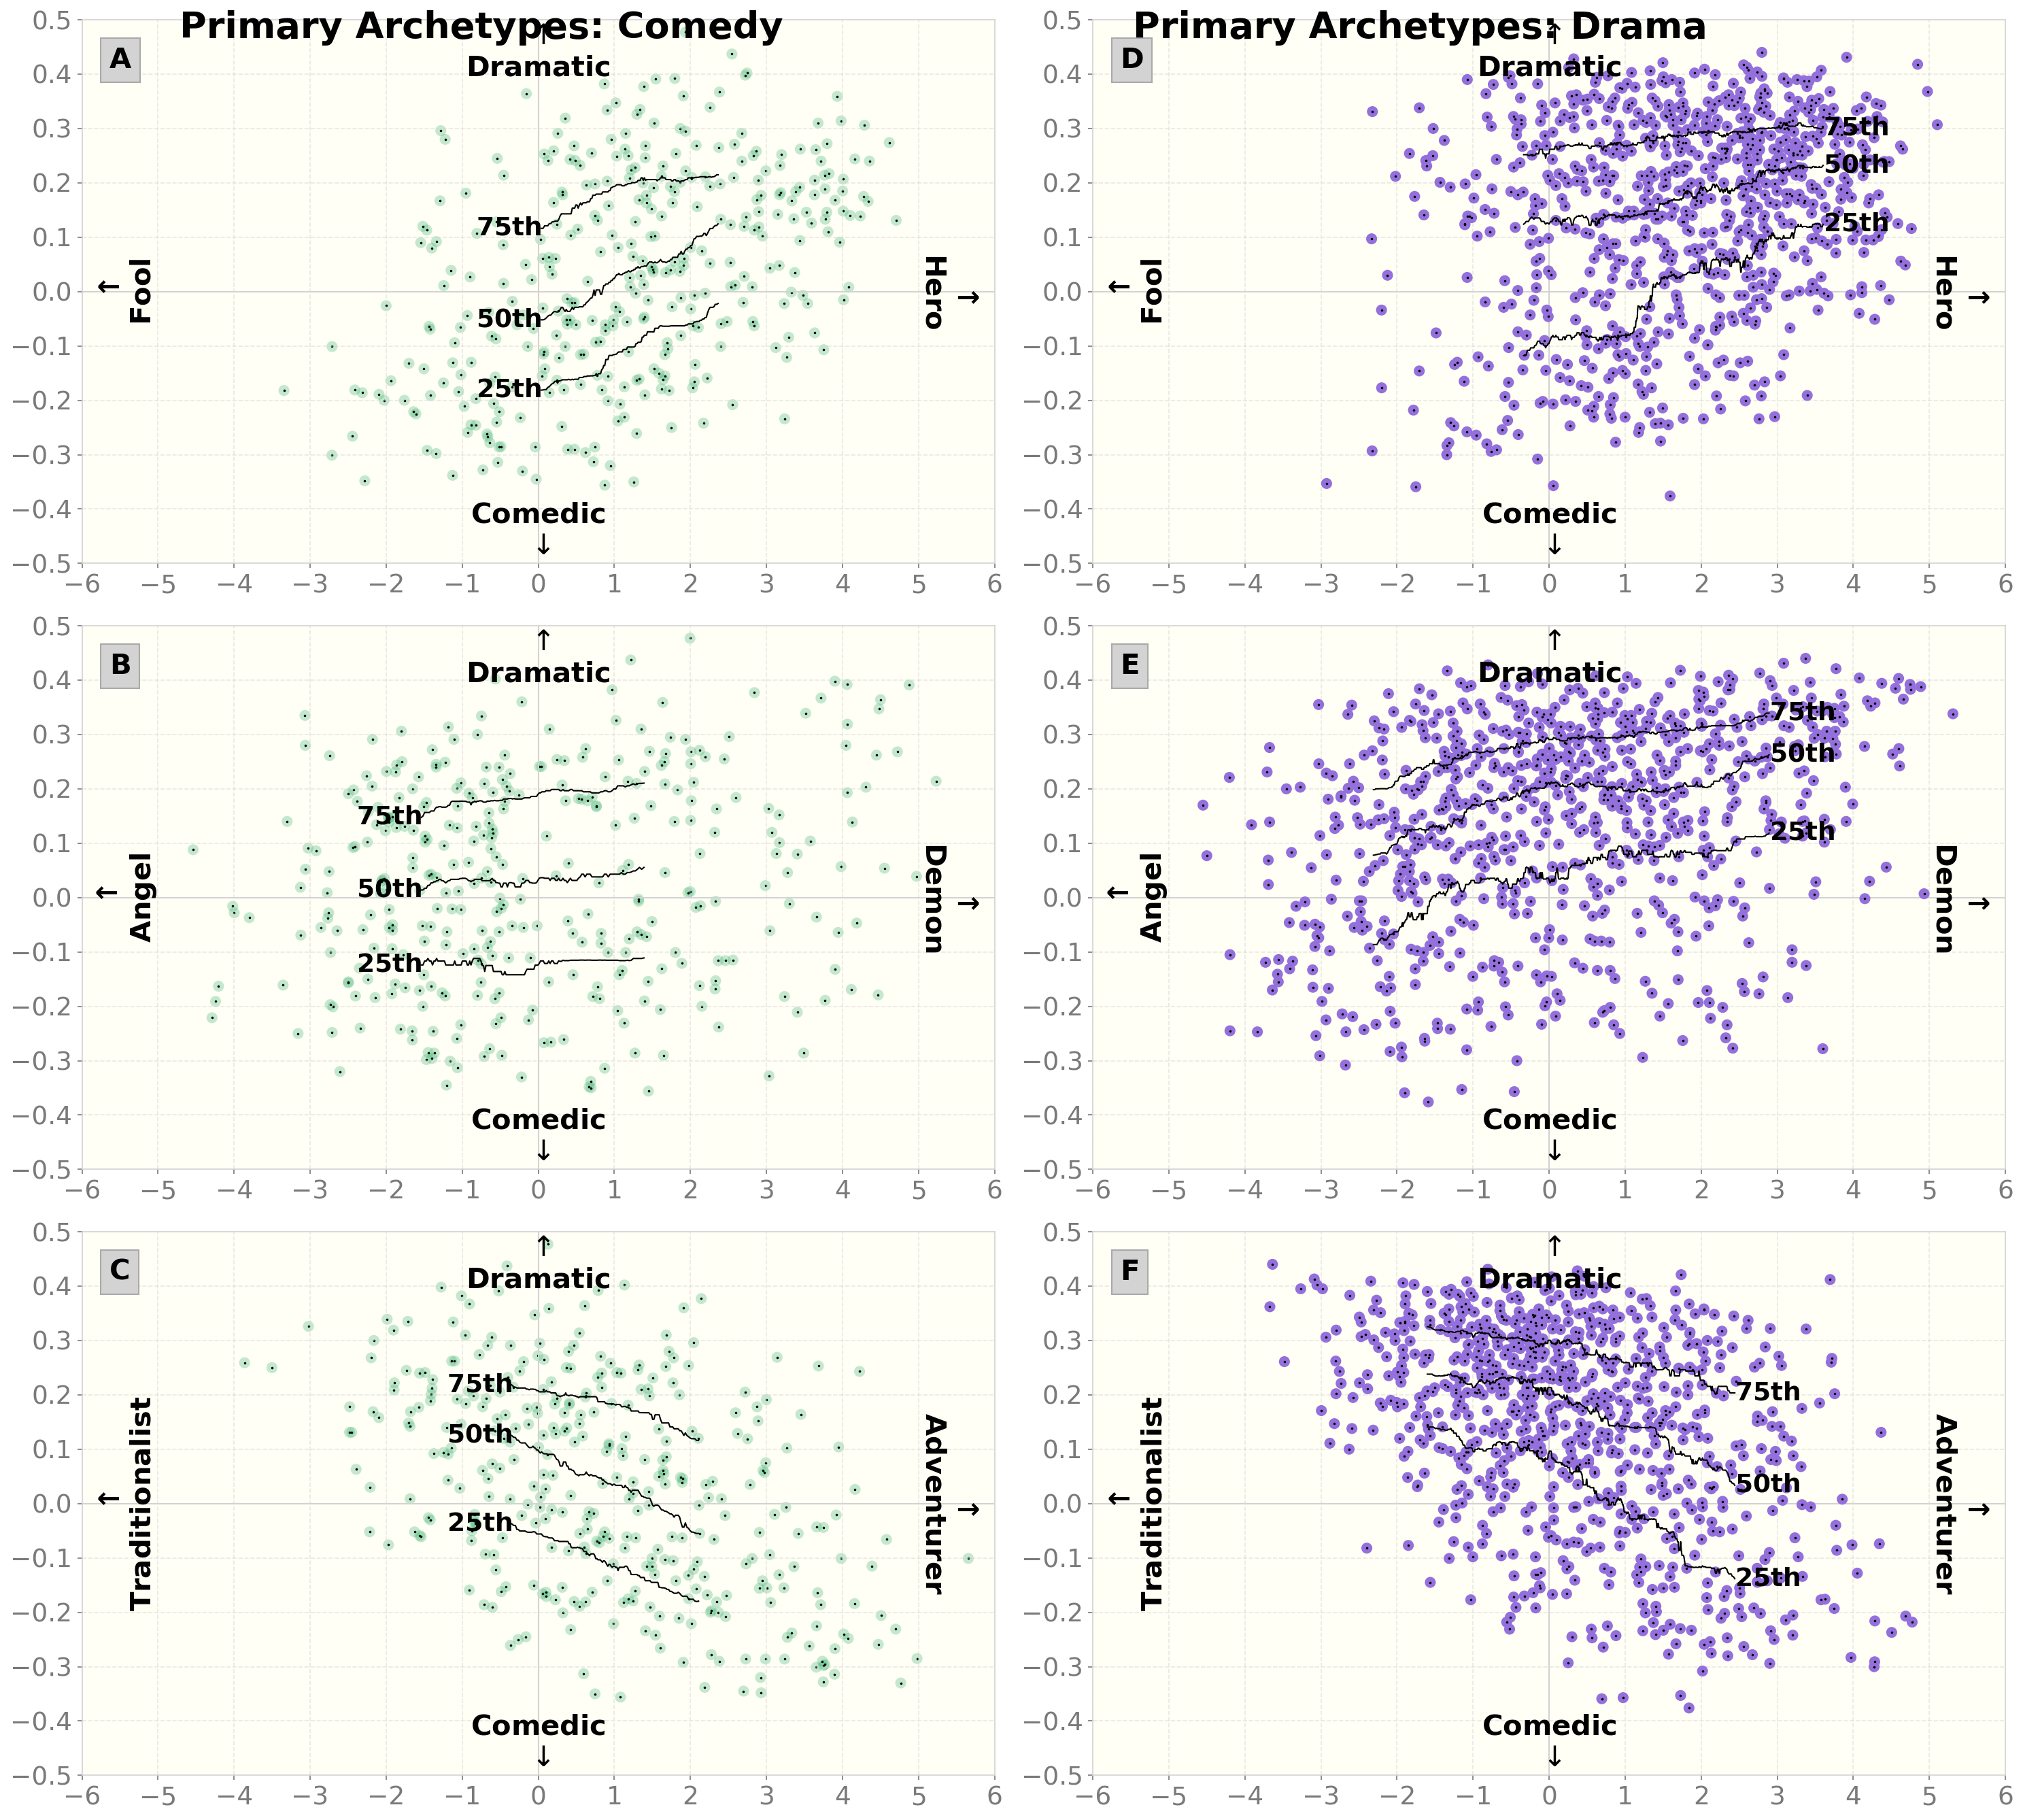

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

y_drama = selected_trait_drama_mf
y_comedy = selected_trait_comedy_mf

x_comedy_list = [selected_comedy_dims[0:1,:], selected_comedy_dims[1:2,:], selected_comedy_dims[2:3,:],
              selected_comedy_dims[3:4,:], selected_comedy_dims[4:5,:], selected_comedy_dims[5:6,:]]
x_drama_list = [selected_drama_dims[0:1,:], selected_drama_dims[1:2,:], selected_drama_dims[2:3,:],
              selected_drama_dims[3:4,:], selected_drama_dims[4:5,:], selected_drama_dims[5:6,:]]

x_labels = [
    "Fool-Hero",
    "Angel-Demon",
    "Traditionalist-Adventurer",
    "Lone Wolf-Diva",
    "Outcast-Sophisticate",
    "Brute-Geek"
]

word_labels_left = ['Fool', 'Angel', 'Traditionalist', 'Lone Wolf', 'Outcast', 'Brute']
word_labels_right = ['Hero', 'Demon', 'Adventurer', 'Diva', 'Sophisticate', 'Geek']
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

fig.text(
    0.24, 0.99,
    "Primary Archetypes: Comedy",
    ha="center", va="top",
    fontsize=26, fontweight="bold"
)

fig.text(
    0.7, 0.99,
    "Primary Archetypes: Drama",
    ha="center", va="top",
    fontsize=26, fontweight="bold"
)

for i in range(3):
    # === Comedy subplot (left) ===
    ax_com = axes[i, 0]
    x_com = x_comedy_list[i].flatten()
    y_com_flat = y_comedy.flatten()

    ax_com.scatter(x_com, y_com_flat, color='mediumseagreen', alpha=0.3,
                   edgecolors='none', s=60)
    ax_com.scatter(x_com, y_com_flat, color='black', s=0.5)
    ax_com.set_facecolor((1.0, 1.0, 0.965))
    add_center_axes(ax_com, color='lightgray')
    ax_com.grid(True, linestyle='--', alpha=0.5)
    ax_com.set_xlim(-6, 6)
    ax_com.set_ylim(-0.5, 0.5)
    ax_com.set_yticks(np.arange(-0.5, 0.51, 0.1))
    ax_com.set_xticks(np.arange(-6, 6.1, 1))
    ax_com.tick_params(axis='x', labelsize=14)
    ax_com.tick_params(axis='y', labelsize=14)

    # === QUARTILE CURVES (comedy) ===
    window_size = 200
    step_size = 1
    percentiles = [25, 50, 75]
    quartile_curves = {p: [] for p in percentiles}
    positions = []

    sort_idx = np.argsort(x_com)
    x_com_sorted = x_com[sort_idx]
    y_com_sorted = y_com_flat[sort_idx]

    for start in range(0, len(x_com_sorted) - window_size + 1, step_size):
        window_y = y_com_sorted[start:start + window_size]
        window_x = x_com_sorted[start:start + window_size]
        q_values = np.percentile(window_y, percentiles)
        for idx, p in enumerate(percentiles):
            quartile_curves[p].append(q_values[idx])
        positions.append(np.mean(window_x))

    for p in percentiles:
        ax_com.plot(positions, quartile_curves[p], color='black', linestyle='-', linewidth=1)
        ax_com.text(positions[0], quartile_curves[p][0], rf'$\mathbf{{{p}th}}$',
                    fontsize=18, va='center', ha='right')

    ax_com.annotate(
        r"$\mathbf{Comedic}$" + "\n" + r"$\downarrow$",
        xy=(0.5, 0.01), xycoords='axes fraction',
        xytext=(0.5, 0.06), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
    )
    ax_com.annotate(
        r"$\uparrow$" + "\n" + r"$\mathbf{Dramatic}$",
        xy=(0.5, 0.99), xycoords='axes fraction',
        xytext=(0.5, 0.94), textcoords='axes fraction',
        ha='center', va='center', fontsize=20
    )

    ax_com.annotate(
        f"$\\mathbf{{\\uparrow}}$\n"
        f"$\\mathbf{{{word_labels_left[i]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.05, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
        rotation=90, rotation_mode='anchor'
    )
    ax_com.annotate(
        f"$\\mathbf{{\\uparrow}}$\n"
        f"$\\mathbf{{{word_labels_right[i]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.95, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
        rotation=270, rotation_mode='anchor'
    )

    # === Drama subplot (right) ===
    ax_dra = axes[i, 1]
    x_dra = x_drama_list[i].flatten()
    y_hor_flat = y_drama.flatten()
    ax_dra.set_facecolor((1.0, 1.0, 0.965))
    ax_dra.scatter(x_dra, y_hor_flat, color='mediumpurple', alpha=1, zorder=2,
                   edgecolors='none', s=60)
    ax_dra.scatter(x_dra, y_hor_flat, color='black', s=0.5, zorder=2)
    add_center_axes(ax_dra, color='lightgray')
    ax_dra.grid(True, linestyle='--', alpha=0.5)
    ax_dra.set_xlim(-6, 6)
    ax_dra.set_ylim(-0.5, 0.5)
    ax_dra.set_yticks(np.arange(-0.5, 0.51, 0.1))
    ax_dra.set_xticks(np.arange(-6, 6.1, 1))

    # === QUARTILE CURVES (drama) ===
    window_size_dra = 200
    quartile_curves_dra = {p: [] for p in percentiles}
    positions_dra = []

    sort_idx_dra = np.argsort(x_dra)
    x_dra_sorted = x_dra[sort_idx_dra]
    y_dra_sorted = y_hor_flat[sort_idx_dra]

    for start in range(0, len(x_dra_sorted) - window_size_dra + 1, step_size):
        window_y = y_dra_sorted[start:start + window_size_dra]
        window_x = x_dra_sorted[start:start + window_size_dra]
        q_values = np.percentile(window_y, percentiles)
        for idx, p in enumerate(percentiles):
            quartile_curves_dra[p].append(q_values[idx])
        positions_dra.append(np.mean(window_x))

    for p in percentiles:
        ax_dra.plot(positions_dra, quartile_curves_dra[p], color='black', linestyle='-', linewidth=1)
        if positions_dra:
            ax_dra.text(positions_dra[-1], quartile_curves_dra[p][-1], rf'$\mathbf{{{p}th}}$',
                        fontsize=18, va='center', ha='left')

    ax_dra.annotate(
        r"$\mathbf{Comedic}$" + "\n" + r"$\downarrow$",
        xy=(0.5, 0.01), xycoords='axes fraction',
        xytext=(0.5, 0.06), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
    )
    ax_dra.annotate(
        r"$\uparrow$" + "\n" + r"$\mathbf{Dramatic}$",
        xy=(0.5, 0.99), xycoords='axes fraction',
        xytext=(0.5, 0.94), textcoords='axes fraction',
        ha='center', va='center', fontsize=20
    )

    ax_dra.annotate(
        f"$\\mathbf{{\\uparrow}}$\n"
        f"$\\mathbf{{{word_labels_left[i]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.05, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
        rotation=90, rotation_mode='anchor'
    )
    ax_dra.annotate(
        f"$\\mathbf{{\\uparrow}}$\n"
        f"$\\mathbf{{{word_labels_right[i]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.95, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
        rotation=270, rotation_mode='anchor'
    )

# Subplot labels
comedy_labels = ['A', 'B', 'C']
drama_labels = ['D', 'E', 'F']

for i in range(3):
    ax_com = axes[i, 0]
    ax_com.text(0.03, 0.95, comedy_labels[i], transform=ax_com.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='left',
                bbox=dict(facecolor='lightgrey', edgecolor='darkgrey', boxstyle='square,pad=0.3'))
    ax_dra = axes[i, 1]
    ax_dra.text(0.03, 0.95, drama_labels[i], transform=ax_dra.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='left',
                bbox=dict(facecolor='lightgrey', edgecolor='darkgrey', boxstyle='square,pad=0.3'))

for ax in axes.flatten():
    ax.tick_params(axis='x', labelsize=18, colors=(0.48,0.48,0.48))
    ax.tick_params(axis='y', labelsize=18, colors=(0.48,0.48,0.48))

plt.subplots_adjust(left=0.02, right=0.94, top=0.97, bottom=0.04,
                    hspace=0.2, wspace=0.15)
plt.tight_layout()
# plt.savefig("../figures/scatter_plot_archetypes_comedy_drama_primary_xor.pdf")
plt.show()

In [ ]:
# === Spearman correlations & quartile summary: Primary Archetypes vs Comedic::Dramatic trait ===
from scipy.stats import spearmanr
import numpy as np

dim_names_primary = ['Fool-Hero', 'Angel-Demon', 'Traditionalist-Adventurer']
y_com = selected_trait_comedy_mf.flatten()
y_dra = selected_trait_drama_mf.flatten()

print(f"Overall medians — Comedy: {np.median(y_com):.3f}, Drama: {np.median(y_dra):.3f}\n")
print(f"{'Dimension':<28} {'rho_com':>8} {'p_com':>10} {'rho_dra':>8} {'p_dra':>10}  "
      f"{'Com Q1-med':>10} {'Com Q3-med':>10} {'Dra Q1-med':>10} {'Dra Q3-med':>10}")
print('-' * 110)

for i, name in enumerate(dim_names_primary):
    x_com = selected_comedy_dims[i].flatten()
    x_dra = selected_drama_dims[i].flatten()

    rho_com, p_com = spearmanr(x_com, y_com)
    rho_dra, p_dra = spearmanr(x_dra, y_dra)

    # Median trait score for characters in bottom/top quartile of archetype axis
    q1_thresh_com = np.percentile(x_com, 25)
    q3_thresh_com = np.percentile(x_com, 75)
    com_q1_med = np.median(y_com[x_com <= q1_thresh_com])
    com_q3_med = np.median(y_com[x_com >= q3_thresh_com])

    q1_thresh_dra = np.percentile(x_dra, 25)
    q3_thresh_dra = np.percentile(x_dra, 75)
    dra_q1_med = np.median(y_dra[x_dra <= q1_thresh_dra])
    dra_q3_med = np.median(y_dra[x_dra >= q3_thresh_dra])

    print(f"{name:<28} {rho_com:>8.3f} {p_com:>10.4f} {rho_dra:>8.3f} {p_dra:>10.4f}  "
          f"{com_q1_med:>10.3f} {com_q3_med:>10.3f} {dra_q1_med:>10.3f} {dra_q3_med:>10.3f}")


## Finding example characters using Convex Hull.

Finding the most extreme points; call original data --> then make sure you can take its convex hull (calculate centroid of all points, calculate the angle to go around in a clockwise fashion to find the convex hull.)

In [ ]:
selected_trait_mf = raw_A[3:4,:].T
selected_trait_comedy0 = raw_A[3:4, comedy_character_list]
selected_trait_drama0 = raw_A[3:4, drama_character_list]
comedy_chars_df.head()

,index,character
0,0,Applejack
1,1,Twilight Sparkle
2,2,Rarity
3,3,Pinkie Pie
4,4,Spike


In [ ]:
# ALL characters, comedy characters, drama characters

id_character = pd.DataFrame({'index': list(range(len(char_names))), 'character': char_names})
id_character['m/f score'] = pd.DataFrame(raw_A[3:4,:].T)
id_character['fool/hero'] = archetype_space_by_genre[0:1].T
id_character['angel/demon'] = archetype_space_by_genre[1:2].T
id_character['traditionalist/adventurer'] = archetype_space_by_genre[2:3].T
id_character['lone wolf/diva'] = archetype_space_by_genre[3:4].T
id_character['outcast/sophisticate'] = archetype_space_by_genre[4:5].T
id_character['brute/geek'] = archetype_space_by_genre[5:6].T

id_character_comedy = pd.DataFrame({'index': comedy_character_list})
id_character_comedy['m/f score'] = list(selected_trait_comedy0.T)
id_character_comedy['character'] = [char_names[i] for i in comedy_character_list]
id_character_comedy['fool/hero'] = selected_comedy_dims[0:1].T
id_character_comedy['angel/demon'] = selected_comedy_dims[1:2].T
id_character_comedy['traditionalist/adventurer'] = selected_comedy_dims[2:3].T
id_character_comedy['lone wolf/diva'] = selected_comedy_dims[3:4].T
id_character_comedy['outcast/sophisticate'] = selected_comedy_dims[4:5].T
id_character_comedy['brute/geek'] = selected_comedy_dims[5:6].T

id_character_drama = pd.DataFrame({'index': drama_character_list})
id_character_drama['m/f score'] = list(selected_trait_drama0.T)
id_character_drama['character'] = [char_names[i] for i in drama_character_list]
id_character_drama['fool/hero'] = selected_drama_dims[0:1].T
id_character_drama['angel/demon'] = selected_drama_dims[1:2].T
id_character_drama['traditionalist/adventurer'] = selected_drama_dims[2:3].T
id_character_drama['lone wolf/diva'] = selected_drama_dims[3:4].T
id_character_drama['outcast/sophisticate'] = selected_drama_dims[4:5].T
id_character_drama['brute/geek'] = selected_drama_dims[5:6].T

Get the convex hull, and the perimter df. Print and see who is on it.

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

# Use drama characters for convex hull analysis
df = id_character_drama.copy()

df["m/f score"] = df["m/f score"].apply(
    lambda x: x.item() if isinstance(x, (list, np.ndarray)) else x
)

# Drop invalid rows
df = df.dropna(subset=["brute/geek", "m/f score"]).reset_index(drop=True)

# Build points
points = df.loc[:, ["brute/geek", "m/f score"]].to_numpy(dtype=float)

# Convex hull
hull = ConvexHull(points)

# Extract perimeter
perimeter_df = df.iloc[hull.vertices].reset_index(drop=True)
perimeter_points = points[hull.vertices]

In [ ]:
import numpy as np

# Ensure clean integer index
perimeter_df = perimeter_df.reset_index(drop=True)

# 1. Centroid
# change for the archetype pairing in question
cx = perimeter_df["brute/geek"].mean()
cy = perimeter_df["m/f score"].mean()

# 2. Angles
angles = np.arctan2(
    perimeter_df["m/f score"] - cy,
    perimeter_df["brute/geek"] - cx
)

# 3. Sort clockwise
perimeter_df = perimeter_df.assign(angle=angles)
perimeter_df = perimeter_df.sort_values("angle", ascending=False).reset_index(drop=True)

# 4. Rotate to start near +x axis (angle closest to 0)
start_pos = (perimeter_df["angle"] - 0).abs().idxmin()

perimeter_df = pd.concat([
    perimeter_df.iloc[start_pos:],
    perimeter_df.iloc[:start_pos]
]).reset_index(drop=True)

# 5. Cleanup
perimeter_df = perimeter_df.drop(columns="angle")


## Secondary Archetypes by Genre

Essentially the same as Primary Archetypes by Genre, just with different dimension indexing.

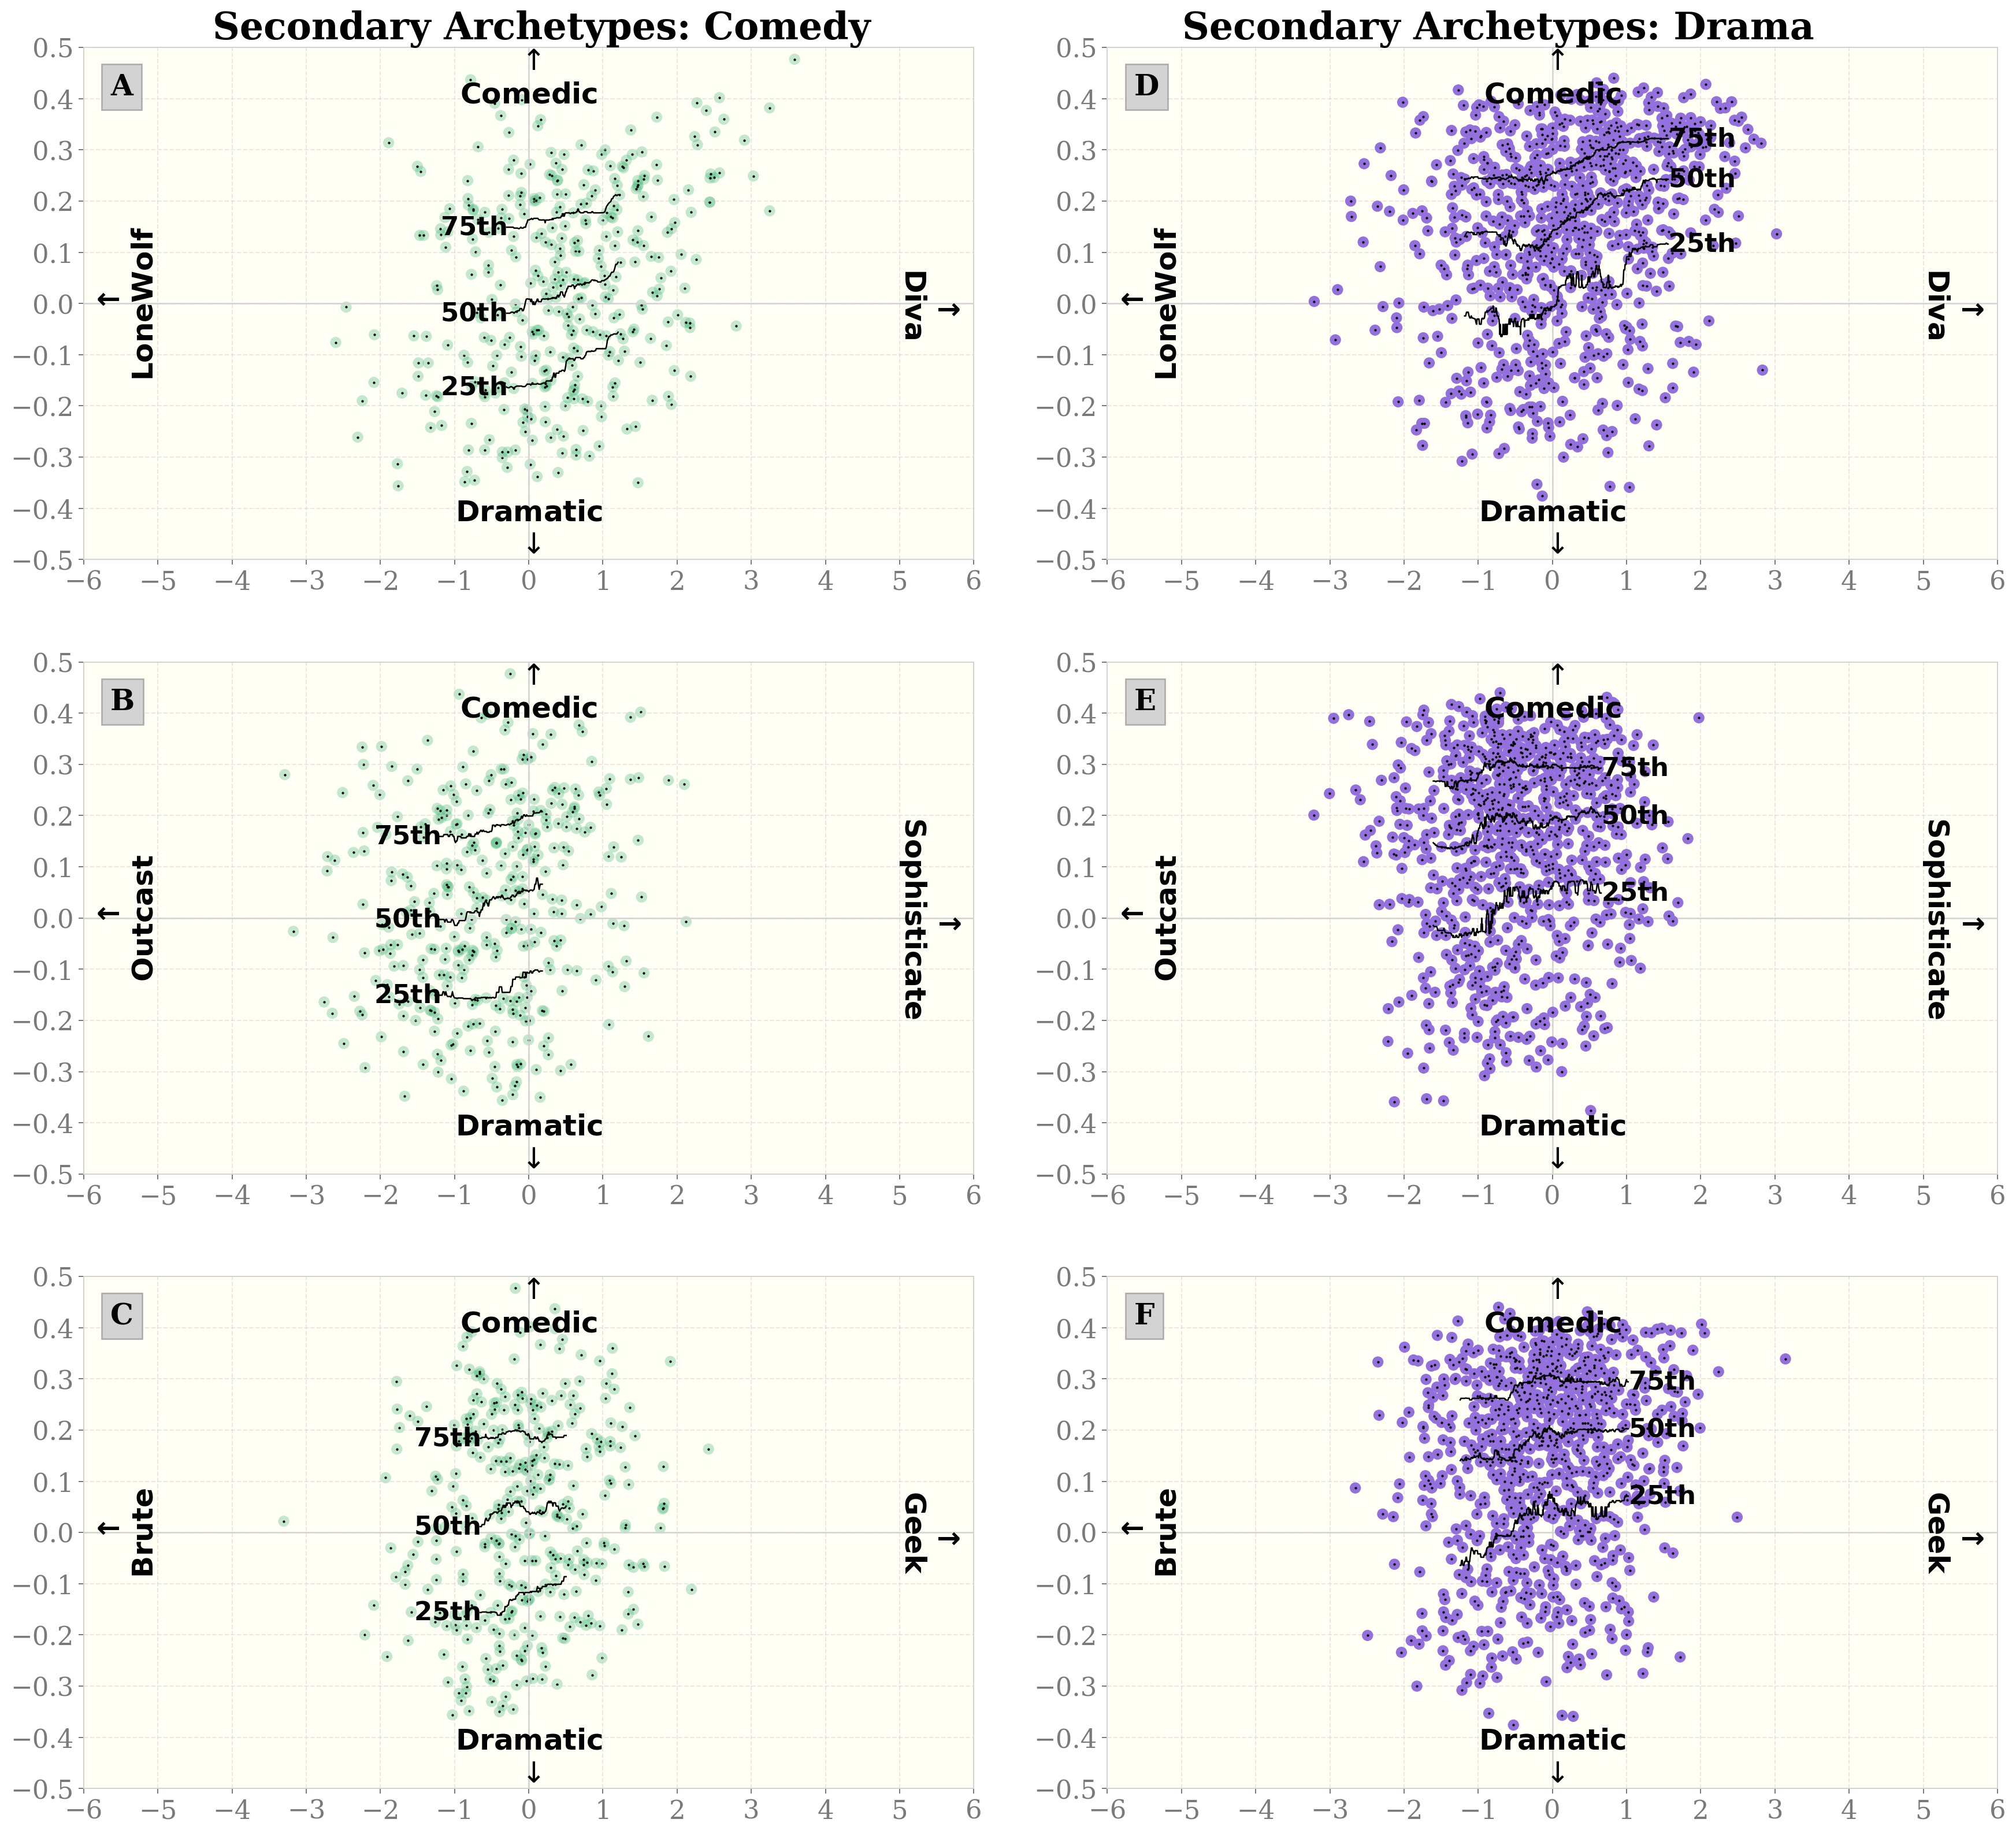

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

y_drama = selected_trait_drama_mf
y_comedy = selected_trait_comedy_mf

# Secondary archetypes: dimensions 3-5
x_comedy_list = [selected_comedy_dims[0:1,:], selected_comedy_dims[1:2,:], selected_comedy_dims[2:3,:],
              selected_comedy_dims[3:4,:], selected_comedy_dims[4:5,:], selected_comedy_dims[5:6,:]]
x_drama_list = [selected_drama_dims[0:1,:], selected_drama_dims[1:2,:], selected_drama_dims[2:3,:],
              selected_drama_dims[3:4,:], selected_drama_dims[4:5,:], selected_drama_dims[5:6,:]]

x_labels = [
    "Fool-Hero",
    "Angel-Demon",
    "Traditionalist-Adventurer",
    "Lone Wolf-Diva",
    "Outcast-Sophisticate",
    "Brute-Geek"
]

word_labels_left = ['Fool', 'Angel', 'Traditionalist', 'Lone Wolf', 'Outcast', 'Brute']
word_labels_right = ['Hero', 'Demon', 'Adventurer', 'Diva', 'Sophisticate', 'Geek']
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.text(
    0.24, 0.99,
    "Secondary Archetypes: Comedy",
    ha="center", va="top",
    fontsize=26, fontweight="bold"
)

fig.text(
    0.7, 0.99,
    "Secondary Archetypes: Drama",
    ha="center", va="top",
    fontsize=26, fontweight="bold"
)

for i in range(3):
    dim_idx = i + 3  # secondary archetypes: dimensions 3, 4, 5

    # === Comedy subplot (left) ===
    ax_com = axes[i, 0]
    x_com = x_comedy_list[dim_idx].flatten()
    y_com_flat = y_comedy.flatten()

    ax_com.scatter(x_com, y_com_flat, color='mediumseagreen', alpha=0.3,
                   edgecolors='none', s=60)
    ax_com.scatter(x_com, y_com_flat, color='black', s=0.5)
    ax_com.set_facecolor((1.0, 1.0, 0.965))
    add_center_axes(ax_com, color='lightgray')
    ax_com.grid(True, linestyle='--', alpha=0.5)
    ax_com.set_xlim(-6, 6)
    ax_com.set_ylim(-0.5, 0.5)
    ax_com.set_yticks(np.arange(-0.5, 0.51, 0.1))
    ax_com.set_xticks(np.arange(-6, 6.1, 1))
    ax_com.tick_params(axis='x', labelsize=14)
    ax_com.tick_params(axis='y', labelsize=14)

    # === QUARTILE CURVES (comedy) ===
    window_size = 200
    step_size = 1
    percentiles = [25, 50, 75]
    quartile_curves = {p: [] for p in percentiles}
    positions = []

    sort_idx = np.argsort(x_com)
    x_com_sorted = x_com[sort_idx]
    y_com_sorted = y_com_flat[sort_idx]

    for start in range(0, len(x_com_sorted) - window_size + 1, step_size):
        window_y = y_com_sorted[start:start + window_size]
        window_x = x_com_sorted[start:start + window_size]
        q_values = np.percentile(window_y, percentiles)
        for idx, p in enumerate(percentiles):
            quartile_curves[p].append(q_values[idx])
        positions.append(np.mean(window_x))

    for p in percentiles:
        ax_com.plot(positions, quartile_curves[p], color='black', linestyle='-', linewidth=1)
        ax_com.text(positions[0], quartile_curves[p][0], rf'$\mathbf{{{p}th}}$',
                    fontsize=18, va='center', ha='right')

    ax_com.annotate(
        r"$\mathbf{Comedic}$" + "\n" + r"$\downarrow$",
        xy=(0.5, 0.01), xycoords='axes fraction',
        xytext=(0.5, 0.06), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
    )
    ax_com.annotate(
        r"$\uparrow$" + "\n" + r"$\mathbf{Dramatic}$",
        xy=(0.5, 0.99), xycoords='axes fraction',
        xytext=(0.5, 0.94), textcoords='axes fraction',
        ha='center', va='center', fontsize=20
    )
    ax_com.annotate(
        f"$\\mathbf{{\\uparrow}}$\n$\\mathbf{{{word_labels_left[dim_idx]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.05, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20, rotation=90, rotation_mode='anchor'
    )
    ax_com.annotate(
        f"$\\mathbf{{\\uparrow}}$\n$\\mathbf{{{word_labels_right[dim_idx]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.95, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20, rotation=270, rotation_mode='anchor'
    )

    # === Drama subplot (right) ===
    ax_dra = axes[i, 1]
    x_dra = x_drama_list[dim_idx].flatten()
    y_hor_flat = y_drama.flatten()
    ax_dra.set_facecolor((1.0, 1.0, 0.965))
    ax_dra.scatter(x_dra, y_hor_flat, color='mediumpurple', alpha=1, zorder=2,
                   edgecolors='none', s=60)
    ax_dra.scatter(x_dra, y_hor_flat, color='black', s=0.5, zorder=2)
    add_center_axes(ax_dra, color='lightgray')
    ax_dra.grid(True, linestyle='--', alpha=0.5)
    ax_dra.set_xlim(-6, 6)
    ax_dra.set_ylim(-0.5, 0.5)
    ax_dra.set_yticks(np.arange(-0.5, 0.51, 0.1))
    ax_dra.set_xticks(np.arange(-6, 6.1, 1))

    # === QUARTILE CURVES (drama) ===
    window_size_dra = 200
    quartile_curves_dra = {p: [] for p in percentiles}
    positions_dra = []

    sort_idx_dra = np.argsort(x_dra)
    x_dra_sorted = x_dra[sort_idx_dra]
    y_dra_sorted = y_hor_flat[sort_idx_dra]

    for start in range(0, len(x_dra_sorted) - window_size_dra + 1, step_size):
        window_y = y_dra_sorted[start:start + window_size_dra]
        window_x = x_dra_sorted[start:start + window_size_dra]
        q_values = np.percentile(window_y, percentiles)
        for idx, p in enumerate(percentiles):
            quartile_curves_dra[p].append(q_values[idx])
        positions_dra.append(np.mean(window_x))

    for p in percentiles:
        ax_dra.plot(positions_dra, quartile_curves_dra[p], color='black', linestyle='-', linewidth=1)
        if positions_dra:
            ax_dra.text(positions_dra[-1], quartile_curves_dra[p][-1], rf'$\mathbf{{{p}th}}$',
                        fontsize=18, va='center', ha='left')

    ax_dra.annotate(
        r"$\mathbf{Comedic}$" + "\n" + r"$\downarrow$",
        xy=(0.5, 0.01), xycoords='axes fraction',
        xytext=(0.5, 0.06), textcoords='axes fraction',
        ha='center', va='center', fontsize=20,
    )
    ax_dra.annotate(
        r"$\uparrow$" + "\n" + r"$\mathbf{Dramatic}$",
        xy=(0.5, 0.99), xycoords='axes fraction',
        xytext=(0.5, 0.94), textcoords='axes fraction',
        ha='center', va='center', fontsize=20
    )
    ax_dra.annotate(
        f"$\\mathbf{{\\uparrow}}$\n$\\mathbf{{{word_labels_left[dim_idx]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.05, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20, rotation=90, rotation_mode='anchor'
    )
    ax_dra.annotate(
        f"$\\mathbf{{\\uparrow}}$\n$\\mathbf{{{word_labels_right[dim_idx]}}}$",
        xy=(0.05, 0.5), xycoords='axes fraction',
        xytext=(0.95, 0.5), textcoords='axes fraction',
        ha='center', va='center', fontsize=20, rotation=270, rotation_mode='anchor'
    )

# Subplot labels
comedy_labels = ['A', 'B', 'C']
drama_labels = ['D', 'E', 'F']

for i in range(3):
    ax_com = axes[i, 0]
    ax_com.text(0.03, 0.95, comedy_labels[i], transform=ax_com.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='left',
                bbox=dict(facecolor='lightgrey', edgecolor='darkgrey', boxstyle='square,pad=0.3'))
    ax_dra = axes[i, 1]
    ax_dra.text(0.03, 0.95, drama_labels[i], transform=ax_dra.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='left',
                bbox=dict(facecolor='lightgrey', edgecolor='darkgrey', boxstyle='square,pad=0.3'))

for ax in axes.flatten():
    ax.tick_params(axis='x', labelsize=18, colors=(0.48,0.48,0.48))
    ax.tick_params(axis='y', labelsize=18, colors=(0.48,0.48,0.48))

plt.subplots_adjust(left=0.02, right=0.94, top=0.97, bottom=0.04,
                    hspace=0.2, wspace=0.15)

plt.tight_layout()
# plt.savefig("../figures/scatter_plot_archetypes_comedy_drama_secondary_xor.pdf")
plt.show()

In [ ]:
# === Spearman correlations & quartile summary: Secondary Archetypes vs Comedic::Dramatic trait ===
from scipy.stats import spearmanr
import numpy as np

dim_names_secondary = ['Lone Wolf-Diva', 'Outcast-Sophisticate', 'Brute-Geek']
y_com = selected_trait_comedy_mf.flatten()
y_dra = selected_trait_drama_mf.flatten()

print(f"{'Dimension':<28} {'rho_com':>8} {'p_com':>10} {'rho_dra':>8} {'p_dra':>10}  "
      f"{'Com Q1-med':>10} {'Com Q3-med':>10} {'Dra Q1-med':>10} {'Dra Q3-med':>10}")
print('-' * 110)

for i, name in enumerate(dim_names_secondary):
    dim_idx = i + 3  # secondary: dims 3, 4, 5
    x_com = selected_comedy_dims[dim_idx].flatten()
    x_dra = selected_drama_dims[dim_idx].flatten()

    rho_com, p_com = spearmanr(x_com, y_com)
    rho_dra, p_dra = spearmanr(x_dra, y_dra)

    # Median trait score for characters in bottom/top quartile of archetype axis
    q1_thresh_com = np.percentile(x_com, 25)
    q3_thresh_com = np.percentile(x_com, 75)
    com_q1_med = np.median(y_com[x_com <= q1_thresh_com])
    com_q3_med = np.median(y_com[x_com >= q3_thresh_com])

    q1_thresh_dra = np.percentile(x_dra, 25)
    q3_thresh_dra = np.percentile(x_dra, 75)
    dra_q1_med = np.median(y_dra[x_dra <= q1_thresh_dra])
    dra_q3_med = np.median(y_dra[x_dra >= q3_thresh_dra])

    print(f"{name:<28} {rho_com:>8.3f} {p_com:>10.4f} {rho_dra:>8.3f} {p_dra:>10.4f}  "
          f"{com_q1_med:>10.3f} {com_q3_med:>10.3f} {dra_q1_med:>10.3f} {dra_q3_med:>10.3f}")


# Trait score by Genre

K-S Statistic: 0.2585, P-value: 0.0000


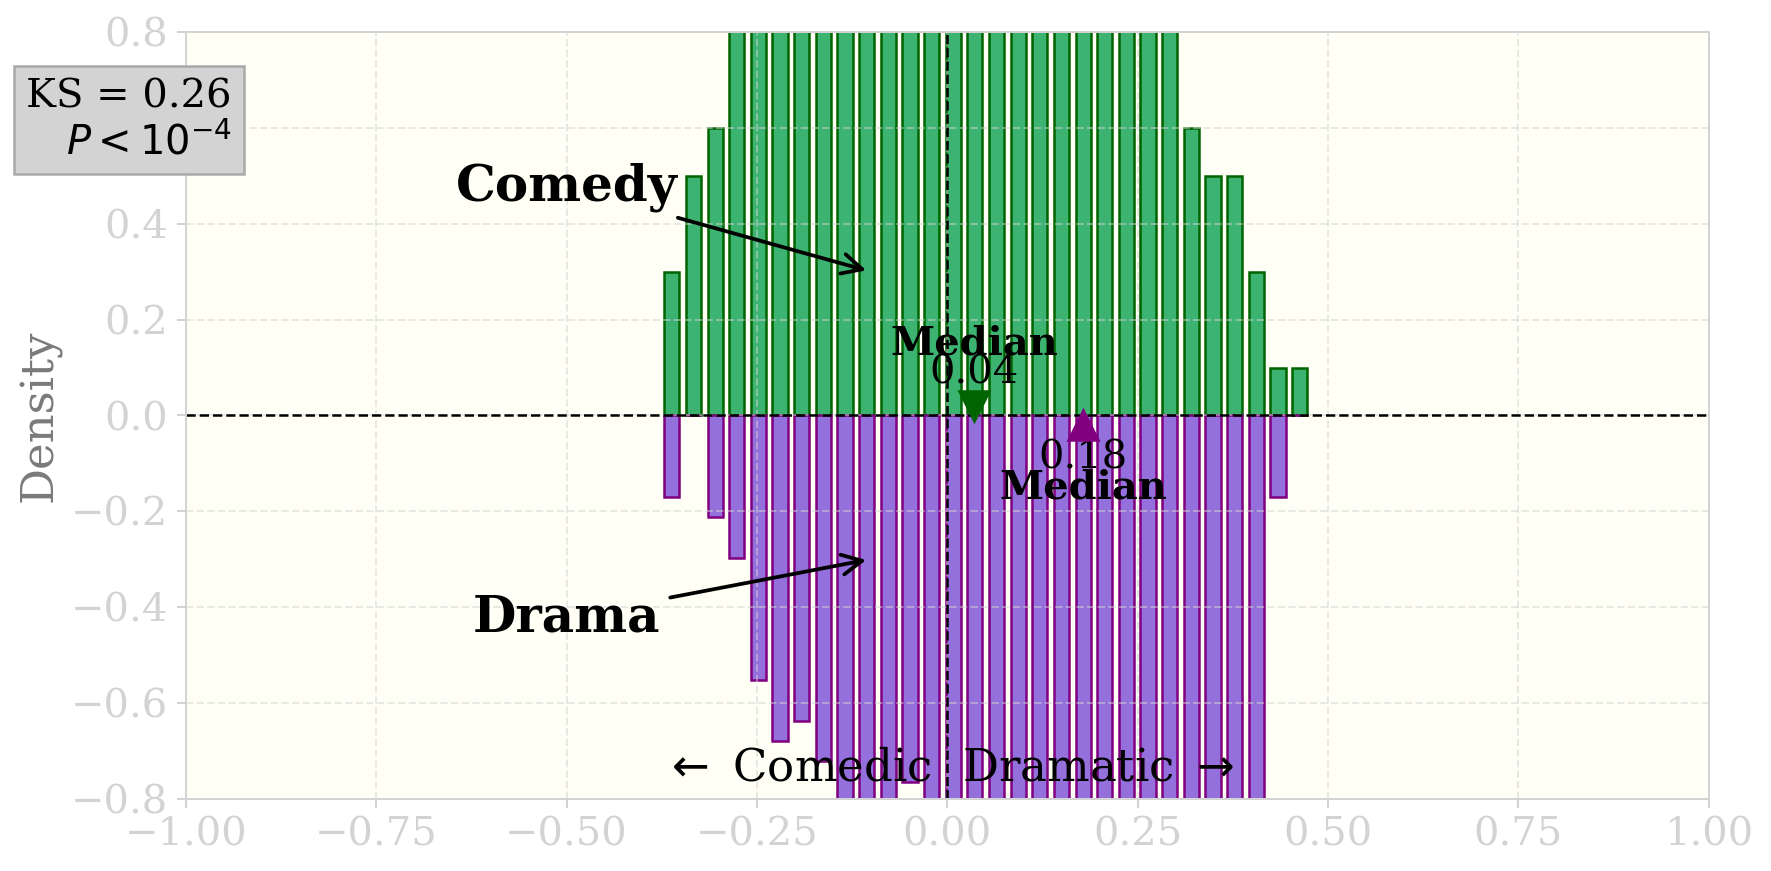

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import ks_2samp
import matplotlib as mpl

# --- LaTeX styling ---
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    'figure.dpi': 180,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    'font.weight': 'normal'
})

# Labels
left_label = "Comedic"
right_label = "Dramatic"

comedy_trait = selected_trait_comedy_mf.flatten()
drama_trait = selected_trait_drama_mf.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

statistic, p_value = ks_2samp(comedy_trait, drama_trait)
print(f"K-S Statistic: {statistic:.4f}, P-value: {p_value:.4f}")

global_min = min(comedy_trait.min(), drama_trait.min())
global_max = max(comedy_trait.max(), drama_trait.max())
bins = np.linspace(global_min, global_max, 31)

comedy_counts, _ = np.histogram(comedy_trait, bins=bins, density=True)
drama_counts, _ = np.histogram(drama_trait, bins=bins, density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

ax.bar(bin_centers, comedy_counts, width=bin_width * 0.7,
       color='mediumseagreen', edgecolor='darkgreen', alpha=1, label='Comedy')
ax.bar(bin_centers, -drama_counts, width=bin_width * 0.7,
       color='mediumpurple', edgecolor='purple', alpha=1, label='Drama')

comedy_median = np.median(comedy_trait)
drama_median = np.median(drama_trait)

ax.text(comedy_median, 0.11, "Median", color='black',
        ha='center', va='bottom', fontsize=16, fontweight='bold')
ax.text(comedy_median, 0.05, f"{comedy_median:.2f}", color='black',
        ha='center', va='bottom', fontsize=16)
ax.plot(comedy_median, 0.02, marker='v', markersize=12,
        color='darkgreen', markeredgecolor='darkgreen', zorder=5)

ax.text(drama_median, -0.11, "Median", color='black',
        ha='center', va='top', fontsize=16, fontweight='bold')
ax.text(drama_median, -0.05, f"{drama_median:.2f}", color='black',
        ha='center', va='top', fontsize=16)
ax.plot(drama_median, -0.02, marker='^', markersize=12,
        color='purple', markeredgecolor='purple', zorder=5)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.grid(True, linestyle='--', alpha=0.5)

p_str = r"$P < 10^{-4}$" if p_value < 1e-4 else f"P = {p_value:.3f}"
ks_text = f"KS = {statistic:.2f}" + "\n" + p_str
ax.text(0.03, 0.94, ks_text, transform=ax.transAxes,
        fontsize=16, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="square,pad=0.3", facecolor="lightgrey", edgecolor="darkgray"))

ax.annotate(
    r"$\leftarrow$ Comedic",
    xy=(0.49, 0.04), xycoords='axes fraction',
    ha='right', va='center', fontsize=18
)
ax.annotate(
    r"Dramatic $\rightarrow$",
    xy=(0.51, 0.04), xycoords='axes fraction',
    ha='left', va='center', fontsize=18
)

ax.annotate('Comedy', xy=(-0.1, 0.3), xytext=(-0.5, 0.45),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            color='black', fontsize=20, fontweight='bold', ha='center')
ax.annotate('Drama', xy=(-0.1, -0.3), xytext=(-0.5, -0.45),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            color='black', fontsize=20, fontweight='bold', ha='center')

ax.set_ylim(-0.8, 0.8)
ax.set_xlim(-1, 1)
ax.set_ylabel('Density', fontsize=18, color=(0.48,0.48,0.48))

plt.tight_layout()
# plt.savefig("../figures/trait_comedic_dramatic_by_genre_xor.pdf", bbox_inches='tight')
plt.show()

# Top Trait Differences: Comedy vs. Drama

Here we compare the mean trait scores for comedy and drama characters across all 464 traits, and visualize the traits that most distinguish the two genres.

In [ ]:
import scipy.io
from scipy.stats import ks_2samp, mannwhitneyu

# Load trait names
mat_local = scipy.io.loadmat('../datasets/archetypometricsdata2000.mat')
trait_typenames = mat_local['data_traits'][0,0]['trait_typenames']  # (464,1)
trait_names = [trait_typenames[i,0][0] for i in range(len(trait_typenames))]
trait_flip = mat_local['data_traits'][0,0]['trait_flip_typenames']  # (464,1) left::right
trait_flip_names = [trait_flip[i,0][0] for i in range(len(trait_flip))]

# Mean trait scores per genre
comedy_traits = raw_A[:, comedy_character_list]  # (464, n_comedy)
drama_traits  = raw_A[:, drama_character_list]   # (464, n_drama)

comedy_means = np.mean(comedy_traits, axis=1)
drama_means = np.mean(drama_traits, axis=1)

# Difference: comedy_mean - drama_mean
diff = comedy_means - drama_means

# K-S statistic for each trait (effect size measure)
ks_stats = np.zeros(len(trait_names))
p_values = np.zeros(len(trait_names))
for j in range(len(trait_names)):
    stat, pval = ks_2samp(comedy_traits[j], drama_traits[j])
    ks_stats[j] = stat
    p_values[j] = pval

# Build summary DataFrame
trait_df = pd.DataFrame({
    'trait': trait_names,
    'trait_flip': trait_flip_names,
    'comedy_mean': comedy_means,
    'drama_mean': drama_means,
    'diff_comedy_minus_drama': diff,
    'abs_diff': np.abs(diff),
    'ks_stat': ks_stats,
    'p_value': p_values
})

# Sort by absolute mean difference
trait_df_sorted = trait_df.sort_values('abs_diff', ascending=False).reset_index(drop=True)
print("Top 20 traits by absolute mean difference (comedy - drama):")
# print(trait_df_sorted[['trait', 'comedy_mean', 'drama_mean', 'diff_comedy_minus_drama', 'ks_stat', 'p_value']].head(20).to_string())
print(trait_df_sorted[['trait', 'diff_comedy_minus_drama', 'ks_stat', 'p_value']].head(20).to_string())

Top 20 traits by absolute mean difference (comedy - drama):
                        trait  diff_comedy_minus_drama   ks_stat       p_value
0        goofy :: unfrivolous                -0.138539  0.273564  8.779405e-17
1          chatty :: reserved                -0.118458  0.248257  7.171584e-14
2      secretive :: open-book                 0.116687  0.231582  4.090905e-12
3         cheery :: sorrowful                -0.115543  0.255641  1.089439e-14
4                sad :: happy                 0.113658  0.280976  1.087203e-17
5         comedic :: dramatic                -0.111712  0.258509  5.138954e-15
6          playful :: serious                -0.111533  0.209747  5.280587e-10
7       coordinated :: clumsy                 0.110311  0.217199  1.063729e-10
8         haunted :: blissful                 0.108154  0.269735  2.529393e-16
9          funny :: humorless                -0.107662  0.232378  3.396020e-12
10  gossiping :: confidential                -0.107359  0.223622  2.547

## Bar chart: Top traits distinguishing comedy from drama

The bar chart below shows the 20 traits with the largest mean difference between comedy and drama characters. Positive values mean comedy characters score higher; negative means drama characters score higher.

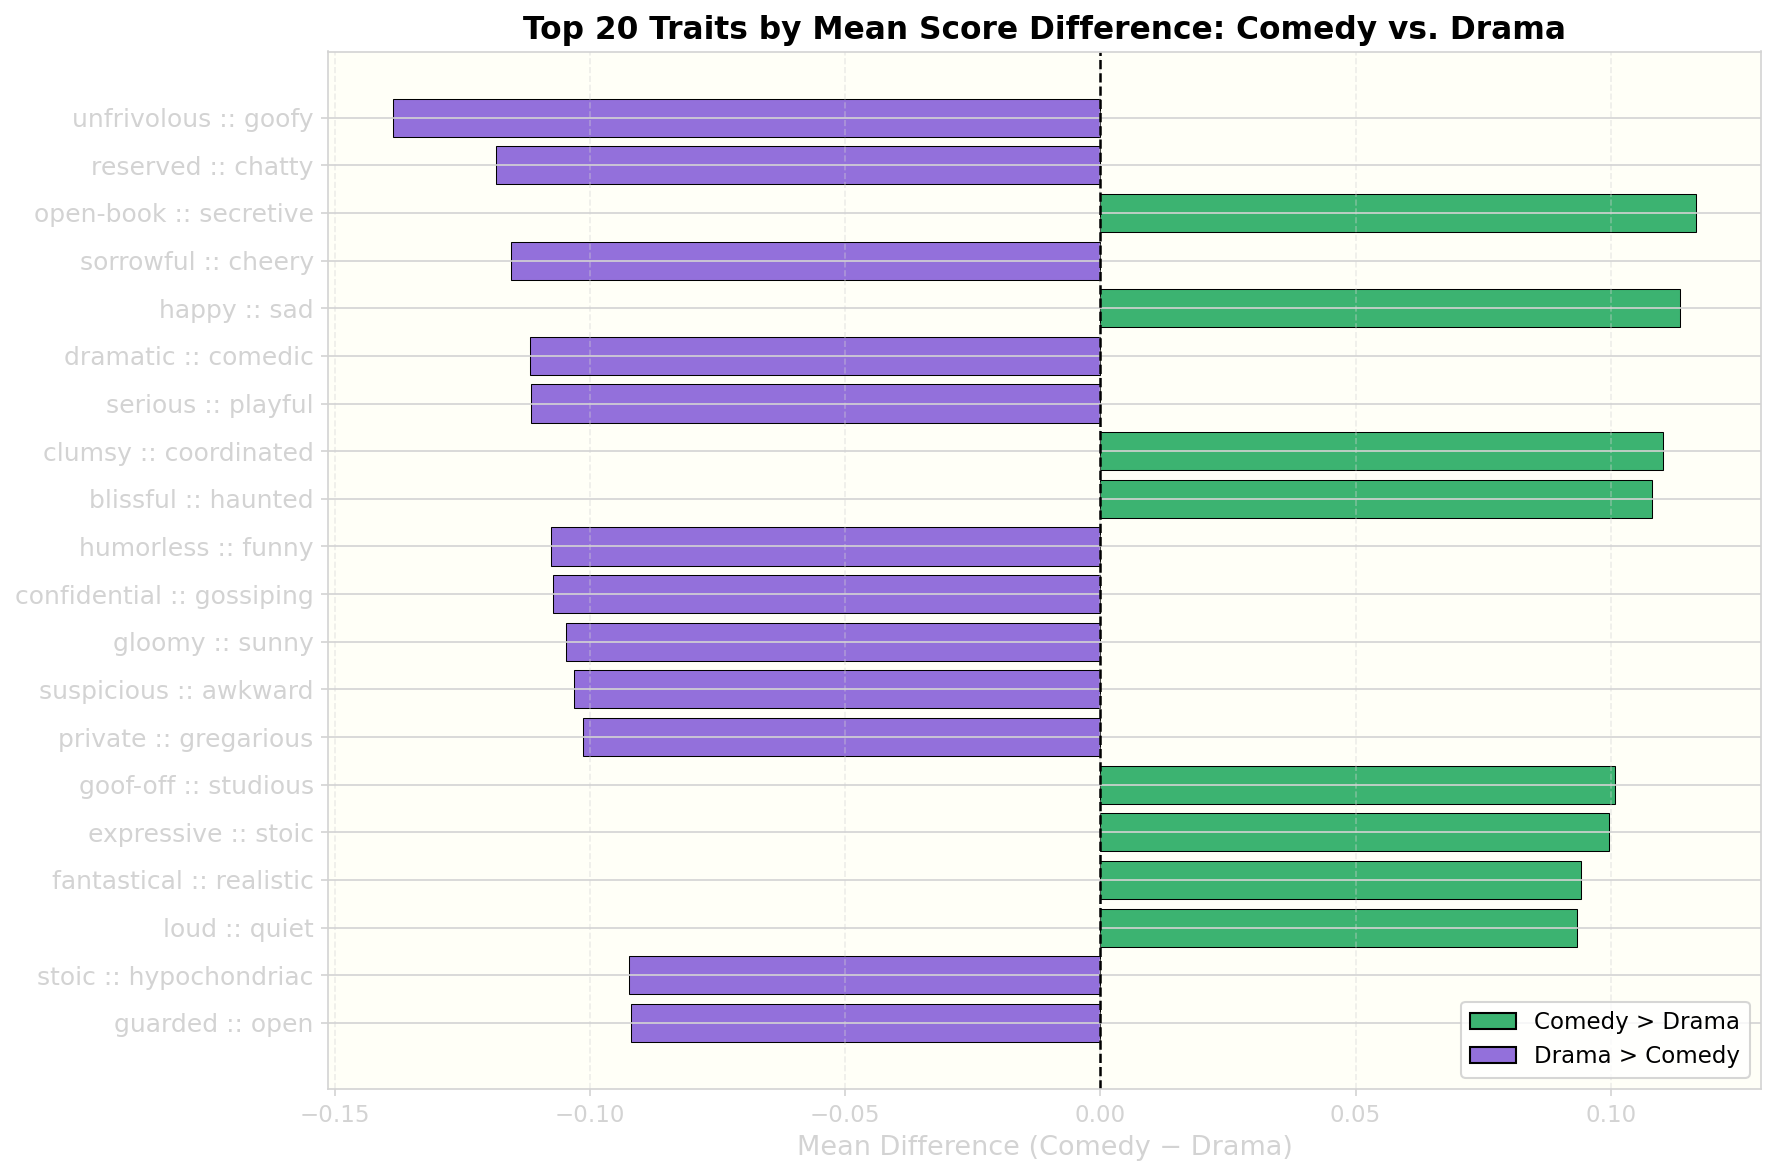

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "axes.labelsize": 13,
    "figure.dpi": 150,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

top_n = 20
top_traits = trait_df_sorted.head(top_n).copy()
# Use the left::right flip name for display
labels = top_traits['trait'].tolist()
diffs = top_traits['diff_comedy_minus_drama'].values

colors = ['mediumseagreen' if d > 0 else 'mediumpurple' for d in diffs]

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor((1.0, 1.0, 0.97))

bars = ax.barh(range(top_n), diffs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels, fontsize=12)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel("Mean Difference (Comedy − Drama)", fontsize=13)
ax.set_title("Top 20 Traits by Mean Score Difference: Comedy vs. Drama", fontsize=15, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='mediumseagreen', edgecolor='black', label='Comedy > Drama'),
                   Patch(facecolor='mediumpurple', edgecolor='black', label='Drama > Comedy')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
# plt.savefig("../figures/top_trait_differences_comedy_drama_bar_xor.pdf", bbox_inches='tight')
plt.show()

In [ ]:
trait_df_sorted[['trait', 'diff_comedy_minus_drama', 'ks_stat']].sort_values('ks_stat', ascending=False).head(20)

,trait,diff_comedy_minus_drama,ks_stat
4,sad :: happy,0.113658,0.280976
0,goofy :: unfrivolous,-0.138539,0.273564
8,haunted :: blissful,0.108154,0.269735
18,hypochondriac :: stoic,-0.092415,0.258660
5,comedic :: dramatic,-0.111712,0.258509
3,cheery :: sorrowful,-0.115543,0.255641
1,chatty :: reserved,-0.118458,0.248257
12,awkward :: suspicious,-0.103086,0.242658
33,epic :: deep,-0.081145,0.237154
28,goth :: flower child,0.084356,0.235905


In [ ]:
# Set threshold at 0.05 p-value for significance
trait_df_sorted[trait_df_sorted['p_value'] <= 0.05].shape

(293, 8)

In [ ]:
trait_df_sorted['abs_diff'].median(), trait_df_sorted['abs_diff'].mean()

(0.031233805445762007, np.float64(0.03659279167234565))

## K-S statistic: Top traits by distributional difference

The K-S statistic captures not just differences in means but in the full distribution shape. Here we show the 20 traits with the highest K-S statistic between comedy and drama characters.

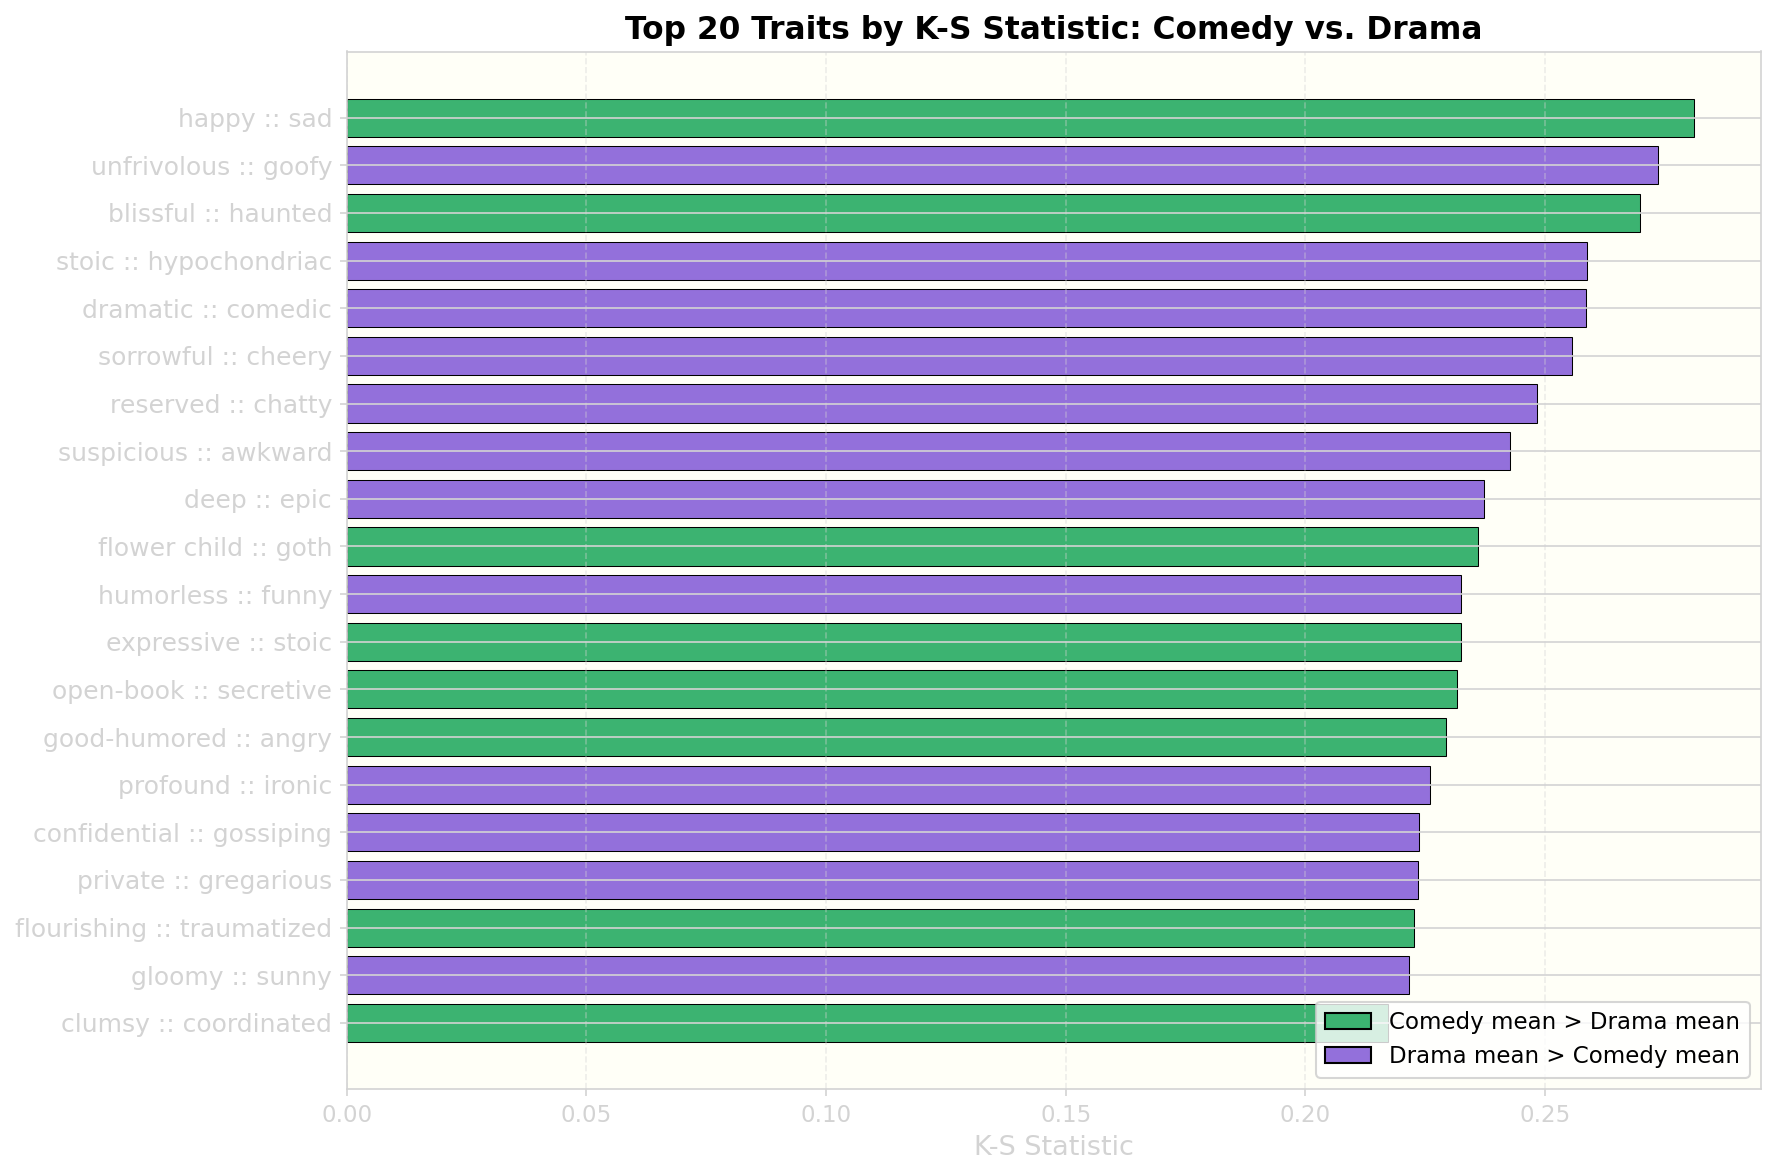

In [ ]:
top_ks = trait_df.sort_values('ks_stat', ascending=False).reset_index(drop=True).head(20)

labels_ks = top_ks['trait'].tolist()
ks_vals = top_ks['ks_stat'].values
diff_dir = top_ks['diff_comedy_minus_drama'].values
colors_ks = ['mediumseagreen' if d > 0 else 'mediumpurple' for d in diff_dir]

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor((1.0, 1.0, 0.97))

ax.barh(range(20), ks_vals, color=colors_ks, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(20))
ax.set_yticklabels(labels_ks, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel("K-S Statistic", fontsize=13)
ax.set_title("Top 20 Traits by K-S Statistic: Comedy vs. Drama", fontsize=15, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

legend_elements = [Patch(facecolor='mediumseagreen', edgecolor='black', label='Comedy mean > Drama mean'),
                   Patch(facecolor='mediumpurple', edgecolor='black', label='Drama mean > Comedy mean')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
# plt.savefig("../figures/top_trait_differences_comedy_drama_ks_xor.pdf", bbox_inches='tight')
plt.show()

## Density plots for the most distinguishing traits

For the top 6 traits by K-S statistic, we plot overlapping density (KDE) curves for comedy and drama characters side by side.

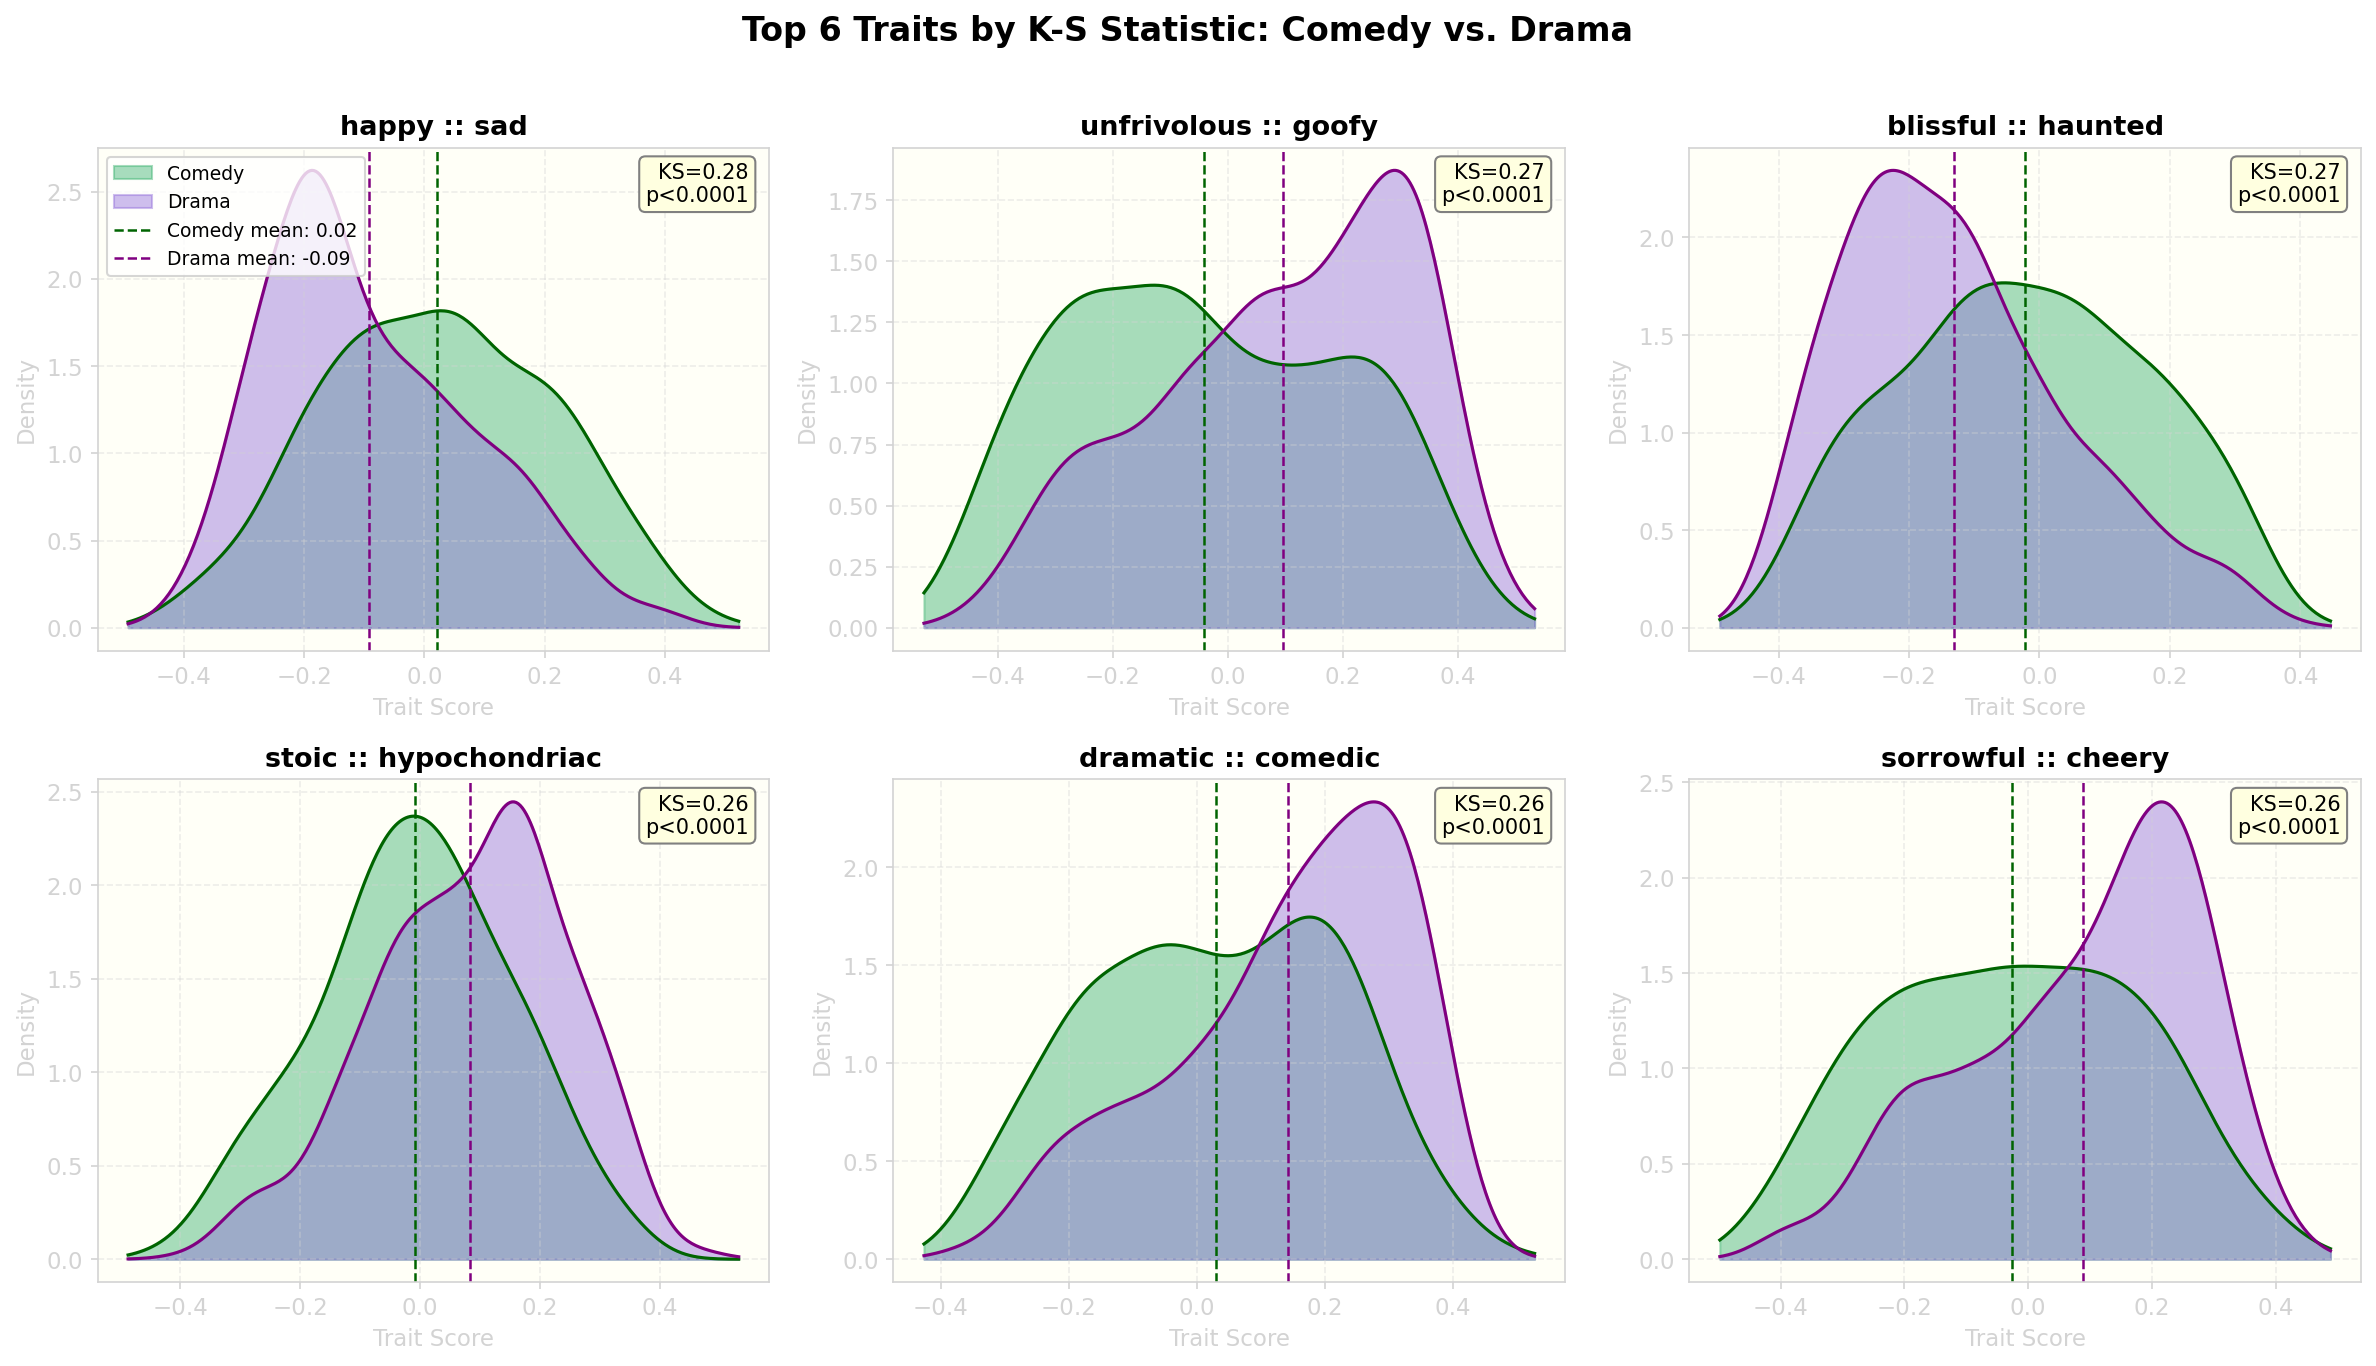

In [ ]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

top6 = trait_df.sort_values('ks_stat', ascending=False).head(6).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, row in top6.iterrows():
    ax = axes[idx]
    trait_idx = trait_names.index(row['trait'])
    comedy_vals = comedy_traits[trait_idx]
    drama_vals = drama_traits[trait_idx]

    # KDE
    x_range = np.linspace(
        min(comedy_vals.min(), drama_vals.min()) - 0.05,
        max(comedy_vals.max(), drama_vals.max()) + 0.05,
        300
    )
    kde_comedy = gaussian_kde(comedy_vals)(x_range)
    kde_drama = gaussian_kde(drama_vals)(x_range)

    ax.fill_between(x_range, kde_comedy, alpha=0.45, color='mediumseagreen', label='Comedy')
    ax.fill_between(x_range, kde_drama, alpha=0.45, color='mediumpurple', label='Drama')
    ax.plot(x_range, kde_comedy, color='darkgreen', linewidth=1.5)
    ax.plot(x_range, kde_drama, color='purple', linewidth=1.5)

    ax.axvline(comedy_vals.mean(), color='darkgreen', linestyle='--', linewidth=1.2, label=f"Comedy mean: {comedy_vals.mean():.2f}")
    ax.axvline(drama_vals.mean(), color='purple', linestyle='--', linewidth=1.2, label=f"Drama mean: {drama_vals.mean():.2f}")

    ax.set_title(row['trait'], fontsize=13, fontweight='bold')
    ax.set_xlabel("Trait Score", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor((1.0, 1.0, 0.97))
    ax.grid(True, linestyle='--', alpha=0.4)

    ks_str = rf"KS={row['ks_stat']:.2f}"
    p_str = f"p<0.0001" if row['p_value'] < 1e-4 else f"p={row['p_value']:.3f}"
    ax.text(0.97, 0.97, f"{ks_str}\n{p_str}", transform=ax.transAxes,
            fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

    if idx == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.suptitle("Top 6 Traits by K-S Statistic: Comedy vs. Drama", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig("../figures/top_trait_density_comedy_drama_xor.pdf", bbox_inches='tight')
plt.show()

### Explore strongest characters in each archetype category in each genre



By signed mean difference, comedy characters score higher on traits associated with levity and social openness: they are chattier (vs.\ reserved), cheerier, more playful (vs.\ serious), funnier (vs.\ humorless), sunnier (vs.\ gloomy), more gossiping (vs.\ confidential), more expressive (vs.\ stoic), more goof-off (vs.\ studious), louder, and more bubbly. Drama characters score higher on traits associated with gravity and emotional weight: more reserved, more sorrowful, more serious, more stoic (vs.\ hypochondriac), more confidential (vs.\ gossiping), deeper (vs.\ epic), and more haunted (vs.\ blissful).
